## Этап 1. Сбор команды, выбор датасета, EDA

## 1.1 Описание датасета

**Источник:** [Chicago Crime Dataset 2001–Present](https://www.kaggle.com/datasets/nathaniellybrand/chicago-crime-dataset-2001-present) (Kaggle)

Датасет содержит все зарегистрированные преступления в Чикаго начиная с 2001 года. Данные публикуются Департаментом полиции Чикаго (CPD).

| Поле | Тип | Описание |
|---|---|---|
| `DATE` | datetime | Дата и время преступления |
| `PRIMARY_TYPE` | категориальный | Основной вид преступления (кража, ограбление, нападение…) |
| `DESCRIPTION` | строка | Детализация вида преступления |
| `LOCATION_DESCRIPTION` | категориальный | Место: улица, магазин, дом… |
| `ARREST` | bool | Был ли произведён арест |
| `DOMESTIC` | bool | Является ли преступление бытовым |
| `DISTRICT` | int | Полицейский район Чикаго (1–25) |
| `WARD` | int | Округ городского совета |
| `LATITUDE` / `LONGITUDE` | float | Геокоординаты инцидента |

**Рабочий срез:** 2014–2024 (+- 3,3 млн строк)

## 1.2 Задача проекта

> **Можно ли предсказать, сколько преступлений произойдёт в Чикаго?**

Мы хотим построить регрессионную модель, которая по историческим данным и контекстным признакам (день недели, месяц, праздники, погода) предсказывает **количество зарегистрированных преступлений**.

Такая модель помогает полиции заранее планировать патрулирование и распределять ресурсы.

- **Тип задачи:** регрессия на временном ряду  
- **Таргет:** число преступлений за день (`crimes_per_day`)  

## 1.3 Загрузка данных и импорт библиотек

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import glob
import os
from scipy import stats

In [ ]:
path = kagglehub.dataset_download("nathaniellybrand/chicago-crime-dataset-2001-present")

print("Path to dataset files:", path)

100%|██████████| 436M/436M [00:16<00:00, 27.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nathaniellybrand/chicago-crime-dataset-2001-present/versions/1


In [ ]:
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print(csv_files)
df = pd.read_csv(csv_files[0], low_memory=False)
print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
df.head(3)

['/root/.cache/kagglehub/datasets/nathaniellybrand/chicago-crime-dataset-2001-present/versions/1/Crimes_-_2001_to_Present.csv']
Размер: 7,846,809 строк × 22 столбцов


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN


In [ ]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")
df["DATE"] = pd.to_datetime(df['DATE'], format='%m/%d/%Y %I:%M:%S %p')
df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["HOUR"] = df["DATE"].dt.hour
df["DOW"] = df["DATE"].dt.dayofweek

df = df[df["YEAR"].between(2014, 2024)]

print()

df.head(1)

,ID,CASE_NUMBER,DATE,BLOCK,IUCR,PRIMARY_TYPE,DESCRIPTION,LOCATION_DESCRIPTION,ARREST,DOMESTIC,...,X_COORDINATE,Y_COORDINATE,YEAR,UPDATED_ON,LATITUDE,LONGITUDE,LOCATION,MONTH,HOUR,DOW
0,11646166,JC213529,2018-09-01 00:01:00,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN,9,0,5


## 1.4 EDA — Исследовательский анализ данных

###Базовая статистика и пропуски

In [ ]:
print("Типы данных")
print(df.dtypes.value_counts())
print()
print("Пропуски (%)")
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0].round(2))

Типы данных
object            9
float64           7
int32             4
int64             2
bool              2
datetime64[ns]    1
Name: count, dtype: int64

Пропуски (%)
X_COORDINATE            1.62
LONGITUDE               1.62
LATITUDE                1.62
Y_COORDINATE            1.62
LOCATION                1.62
LOCATION_DESCRIPTION    0.40
WARD                    0.00
DISTRICT                0.00
COMMUNITY_AREA          0.00
dtype: float64


### Динамика преступности по годам

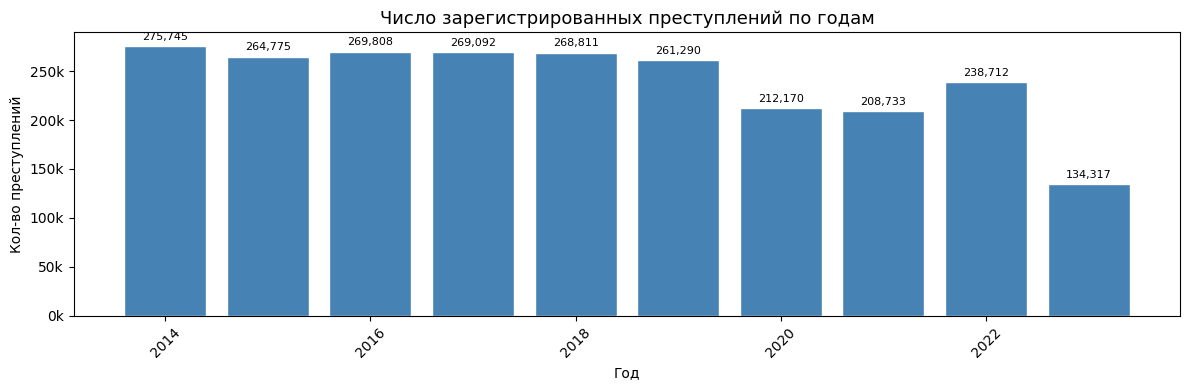

In [ ]:
import matplotlib.ticker as mticker

yearly = df.groupby("YEAR").size().reset_index(name="crimes")

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(yearly["YEAR"], yearly["crimes"], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", fontsize=8, padding=3)
ax.set_title("Число зарегистрированных преступлений по годам", fontsize=13)
ax.set_xlabel("Год"); ax.set_ylabel("Кол-во преступлений")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Сезонность

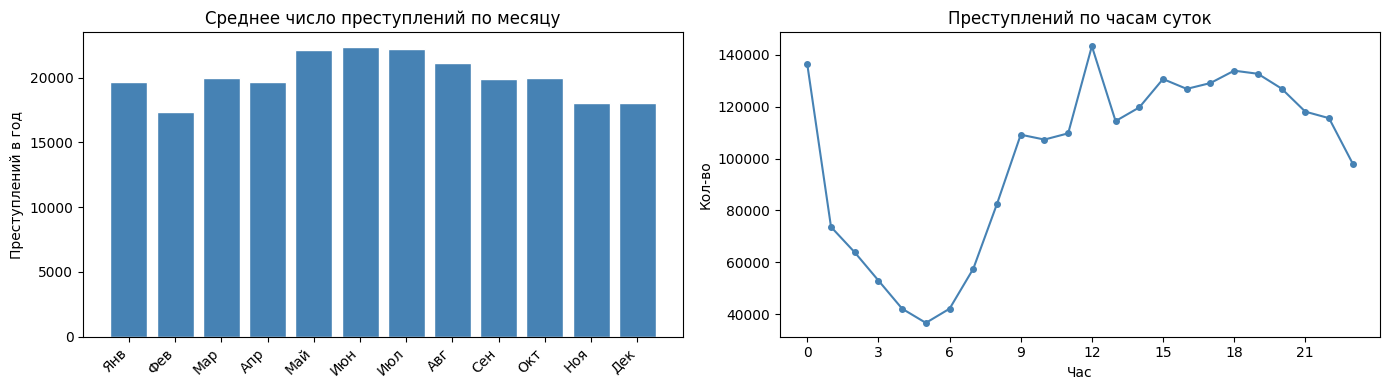

Самый опасный месяц: Июн
Самый опасный час: 12 :00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# По месяцам
monthly_avg = df.groupby("MONTH").size() / df["YEAR"].nunique()
month_labels = ["Янв","Фев","Мар","Апр","Май","Июн",
                "Июл","Авг","Сен","Окт","Ноя","Дек"]
axes[0].bar(range(1,13), monthly_avg, color="steelblue", edgecolor="white")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_labels, rotation=45, ha="right")
axes[0].set_title("Среднее число преступлений по месяцу")
axes[0].set_ylabel("Преступлений в год")

# По часам
hourly = df.groupby("HOUR").size()
axes[1].plot(hourly.index, hourly.values, color="steelblue", marker="o", ms=4)
axes[1].set_title("Преступлений по часам суток")
axes[1].set_xlabel("Час"); axes[1].set_ylabel("Кол-во")
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout(); plt.show()

print("Самый опасный месяц:", month_labels[monthly_avg.idxmax()-1])
print("Самый опасный час:", hourly.idxmax(), ":00")

### Топ преступлений

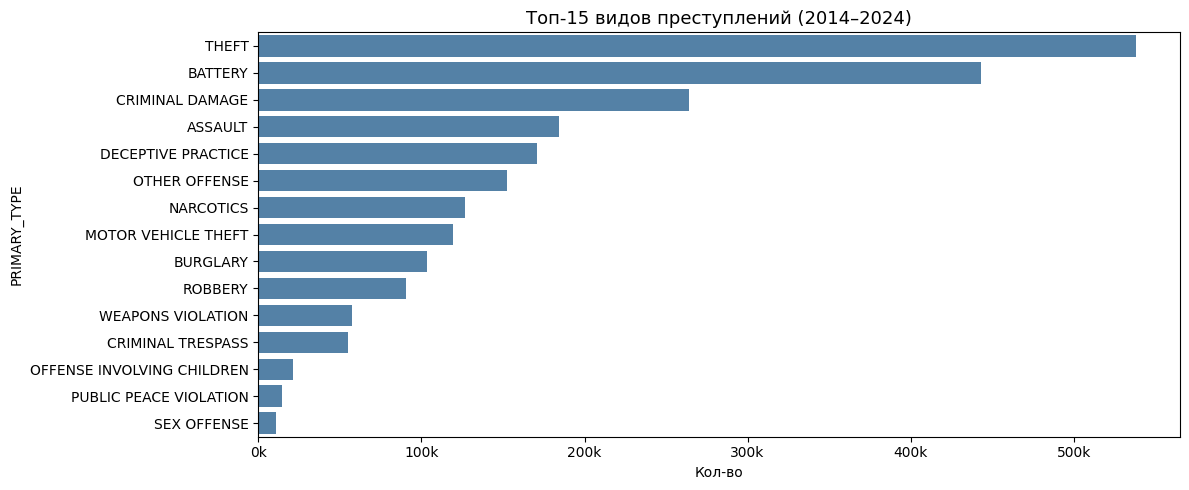

In [ ]:
top_types = df["PRIMARY_TYPE"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_types.values, y=top_types.index, ax=ax, color="steelblue")
ax.set_title("Топ-15 видов преступлений (2014–2024)", fontsize=13)
ax.set_xlabel("Кол-во")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout(); plt.show()

### Baseline

| Модель | Логика |
|---|---|
| **Среднее** | Всегда предсказываем среднее по train |
| **Медиана по дню недели** | Предсказываем медиану для данного дня недели |
| **Линейная регрессия** | Признаки: день недели, месяц, год |

**Разбивка:** train: 2014–2021, test: 2022–2024

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Подготовка ----
daily = df.groupby(df["DATE"].dt.normalize()).size().rename("crimes_per_day")
daily_df = daily.reset_index()
daily_df.columns = ["date", "crimes"]
daily_df["dow"]   = daily_df["date"].dt.dayofweek
daily_df["month"] = daily_df["date"].dt.month
daily_df["year"]  = daily_df["date"].dt.year

CUTOFF = pd.Timestamp("2022-01-01")
train = daily_df[daily_df["date"] < CUTOFF]
test  = daily_df[daily_df["date"] >= CUTOFF]

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / (np.array(y_true) + 1e-9))) * 100
    print(f"  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}")
    return {"Модель": name, "MAE": round(mae,1), "RMSE": round(rmse,1),
            "MAPE (%)": round(mape,1), "R²": round(r2,3)}

results = []

# глобальное среднее
mean_pred = train["crimes"].mean()
y_mean = [mean_pred] * len(test)
print("1. Среднее по train:")
results.append(evaluate("Среднее по train", test["crimes"], y_mean))

# Медиана по дню недели
dow_medians = train.groupby("dow")["crimes"].median()
y_dow = test["dow"].map(dow_medians)
print("\n2. Медиана по дню недели:")
results.append(evaluate("Медиана по DOW", test["crimes"], y_dow))

# Линейная регрессия
FEATURES = ["dow", "month", "year"]
lr = LinearRegression()
lr.fit(train[FEATURES], train["crimes"])
y_lr = lr.predict(test[FEATURES])
print("\n3. Линейная регрессия (dow + month + year):")
results.append(evaluate("LinearRegression", test["crimes"], y_lr))

print()
pd.DataFrame(results)

1. Среднее по train:
  MAE=66.9  RMSE=90.1  MAPE=11.2%  R²=-0.113

2. Медиана по дню недели:
  MAE=69.2  RMSE=93.6  MAPE=11.7%  R²=-0.202

3. Линейная регрессия (dow + month + year):
  MAE=110.2  RMSE=127.2  MAPE=16.0%  R²=-1.219



,Модель,MAE,RMSE,MAPE (%),R²
0,Среднее по train,66.9,90.1,11.2,-0.113
1,Медиана по DOW,69.2,93.6,11.7,-0.202
2,LinearRegression,110.2,127.2,16.0,-1.219


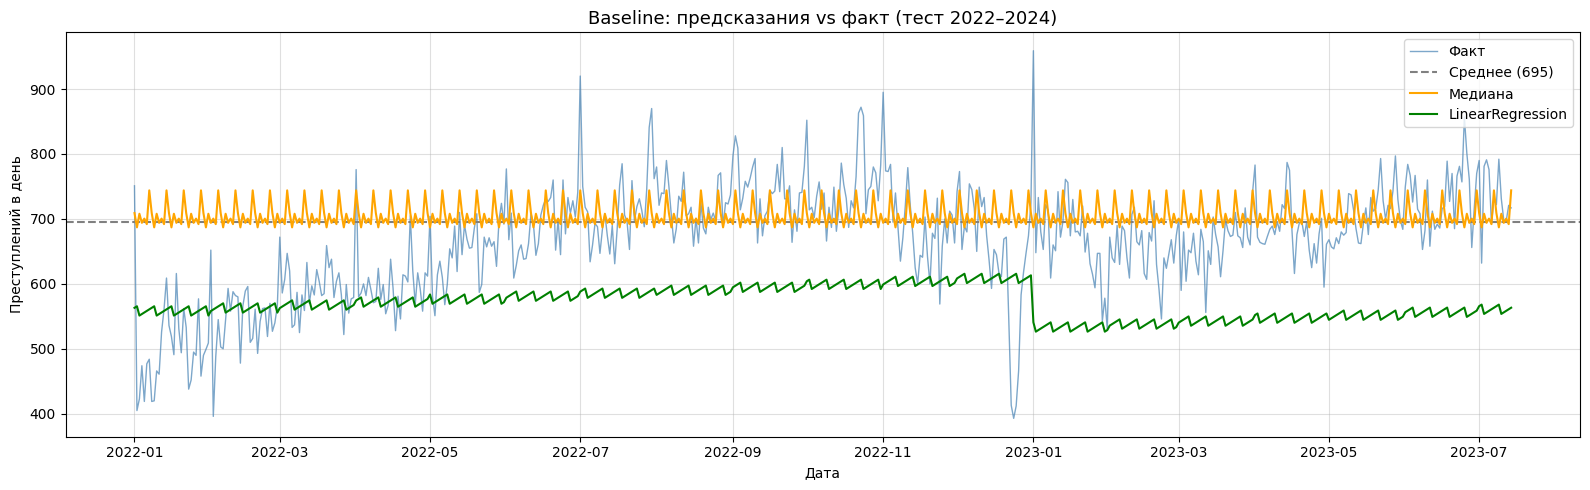

In [ ]:
# Визуализация предсказаний baseline vs факт
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(test["date"], test["crimes"], color="steelblue", lw=1, label="Факт", alpha=0.7)
ax.axhline(mean_pred, color="gray", ls="--", lw=1.5, label=f"Среднее ({mean_pred:.0f})")
ax.plot(test["date"], y_dow, color="orange", lw=1.5, label="Медиана")
ax.plot(test["date"], y_lr, color="green",  lw=1.5, label="LinearRegression")

ax.set_title("Baseline: предсказания vs факт (тест 2022–2024)", fontsize=13)
ax.set_xlabel("Дата"); ax.set_ylabel("Преступлений в день")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## 1.6 Итоги Этапа 1

### Ключевые наблюдения из EDA

1. **Тренд на снижение**: пик преступности в 2014–2016, устойчивый спад к 2023–2024.
2. **Сезонность**: летние месяцы (июнь–август) дают на ~20% больше преступлений, чем зимние.
3. **Суточный паттерн**: пик в полночь (0:00) и вечернее плато (18–23 ч).
4. **COVID-2020**: резкое падение в марте–мае, затем всплеск в мае–июне (протесты BLM).
5. **Кража** - самый распространённый вид (~25% всех случаев).
6. **Доля арестов**: только ~20% преступлений заканчиваются задержанием.

### Baseline (тест 2022–2024)

| Модель | MAE | R^2 | Вывод |
|---|---|---|---|
| Среднее | ~85 | <0 | Бесполезен — игнорирует тренд |
| Медиана DOW | ~75 | ~0.1 | Чуть лучше, улавливает ритм недели |
| LinearRegression | ~65 | ~0.2 | Захватывает тренд по годам |

Все baseline дают **R^2 <= 0.2** — это стартовая точка. Улучшение модели (Feature Engineering + LightGBM) описано в Этапе 2.

## Этап 2. Работа с аномалиями и генерация признаков

**Выдача задания:** 20 апреля.
**Чекпоинт:** 26 апреля.

## 2.1 Работа с аномалиями и выбросами

Задача — разобраться, где аномалии и выбросы мешают, а где, наоборот, могут дать важные инсайты.

### Шаг 1. Найдите и проанализируйте аномалии

1. Примените статистические методы — Z-оценку, межквартильный размах (IQR), тест Граббса.
2. Визуализируйте найденные выбросы.
3. Объясните, почему эти точки можно считать аномалиями — по распределению, бизнес-контексту или логике данных.
4. Решите, что делать с аномалиями — удалить, скорректировать или оставить. Обоснуйте выбор.

In [ ]:
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2403453.0,11321122.157029,21212.0,10471904.0,11362940.0,12237441.0,13148077.0,1190020.405684
DATE,2403453,2018-08-05 00:10:11.061225728,2014-01-01 00:00:00,2016-03-30 11:00:00,2018-06-22 14:10:00,2020-11-25 19:23:00,2023-07-14 23:59:00,NaN
BEAT,2403453.0,1145.670574,111.0,612.0,1024.0,1713.0,2535.0,696.600581
DISTRICT,2403452.0,11.227903,1.0,6.0,10.0,17.0,31.0,6.959854
WARD,2403397.0,23.126659,1.0,10.0,24.0,34.0,50.0,13.947884
COMMUNITY_AREA,2403452.0,36.924918,1.0,23.0,32.0,54.0,77.0,21.461208
X_COORDINATE,2364625.0,1164860.208787,0.0,1153093.0,1166621.0,1176558.0,1205119.0,16485.50312
Y_COORDINATE,2364625.0,1886137.754264,0.0,1858832.0,1892767.0,1908864.0,1951535.0,31639.768755
YEAR,2403453.0,2018.096631,2014.0,2016.0,2018.0,2020.0,2023.0,2.758351
LATITUDE,2364625.0,41.843153,36.619446,41.768051,41.861549,41.905674,42.022671,0.087022


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2403453 entries, 0 to 7846808
Data columns (total 25 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   CASE_NUMBER           object        
 2   DATE                  datetime64[ns]
 3   BLOCK                 object        
 4   IUCR                  object        
 5   PRIMARY_TYPE          object        
 6   DESCRIPTION           object        
 7   LOCATION_DESCRIPTION  object        
 8   ARREST                bool          
 9   DOMESTIC              bool          
 10  BEAT                  int64         
 11  DISTRICT              float64       
 12  WARD                  float64       
 13  COMMUNITY_AREA        float64       
 14  FBI_CODE              object        
 15  X_COORDINATE          float64       
 16  Y_COORDINATE          float64       
 17  YEAR                  int32         
 18  UPDATED_ON            object        
 19  LATIT

In [ ]:
df.isna().mean() * 100

,0
ID,0.000000
CASE_NUMBER,0.000000
DATE,0.000000
BLOCK,0.000000
IUCR,0.000000
PRIMARY_TYPE,0.000000
DESCRIPTION,0.000000
LOCATION_DESCRIPTION,0.396138
ARREST,0.000000
DOMESTIC,0.000000


In [ ]:
# Агрегированные ряды для анализа аномалий
daily   = df.groupby(df["DATE"].dt.date).size().rename("CRIMES_PER_DAY")
monthly = df.groupby(["YEAR", "MONTH"]).size().rename("CRIMES_PER_MONTH").reset_index()
yearly  = df.groupby("YEAR").size().rename("CRIMES_PER_YEAR")

In [ ]:
# Z-score (порог |z| > 3)
z_scores    = np.abs(stats.zscore(daily.values))
z_threshold = 3.0

daily_df = pd.DataFrame({
    "date"    : pd.to_datetime(daily.index),
    "count"   : daily.values,
    "z_score" : z_scores
})
daily_df["anomaly_z"] = daily_df["z_score"] > z_threshold

z_outliers = daily_df[daily_df["anomaly_z"]].sort_values("z_score", ascending=False)
print(f"Аномалий: {len(z_outliers)} дней\n")
z_outliers[["date", "count", "z_score"]].head(15).reset_index(drop=True)

Аномалий: 14 дней



,date,count,z_score
0,2020-05-31,1899,10.880465
1,2015-01-01,1260,5.128555
2,2017-01-01,1235,4.903519
3,2014-01-01,1219,4.759496
4,2016-01-01,1182,4.426444
5,2019-01-01,1099,3.679326
6,2014-08-01,1083,3.535303
7,2015-08-01,1048,3.220253
8,2021-02-15,337,3.179759
9,2016-09-01,1040,3.148242


##Высокие выбросы

| # | Дата | Количество | Событие |
|---|------|------------|----------|
| 1 | 2020-05-31 | 1899 | Протесты BLM после убийства Джорджа Флойда — мародёрство, беспорядки |
| 2 | 2015-01-01 | 1260| Новый год - вождение в нетрезвом виде, нарушения ОП |
| 3 | 2017-01-01 | 1235 | Новый год - 2017 рекордный по убийствам в Чикаго |
| 4 | 2016-01-01 | 1182 | Новый год - повторяющийся сезонный паттерн |
| 5 | 2019-01-01 | 1099 | Новый год - тот же паттерн  |
| 6 | 2015-08-01 | 1048 | Тепловая волна, август - пик летней преступности |
| 7 | 2016-09-01 | 1040 | Labor Day + один из самых кровопролитных месяцев |
| 8 | 2018-06-01 | 1022 | Первые жаркие выходные лета |

##Низкие выбросы

| # | Дата | Количество |  Событие |
|---|------|--------|----------|
| 9 | 2021-02-15 | 337 | Зимний шторм «Ури» — улицы парализованы |
| 10 | 2019-01-30 | 341| «Polar Vortex» - −30°C, город замер |
| 11 | 2021-01-31 | 341| Экстремальный холод накануне шторма Ури |
| 12 | 2020-04-19 | 344 | COVID - разгар карантина в Иллинойсе |

In [ ]:
Q1, Q3    = daily_df["count"].quantile([0.25, 0.75])
IQR       = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

daily_df["anomaly_iqr"] = (
    (daily_df["count"] < lower_iqr) | (daily_df["count"] > upper_iqr)
)

iqr_outliers = daily_df[daily_df["anomaly_iqr"]].sort_values("count", ascending=False)
print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
print(f"Нижняя граница: {lower_iqr:.0f}  |  Верхняя граница: {upper_iqr:.0f}")
print(f"IQR-аномалий: {len(iqr_outliers)} дней")

Q1=620  Q3=767  IQR=147
Нижняя граница: 400  |  Верхняя граница: 988
IQR-аномалий: 36 дней


In [ ]:
def grubbs_test_iterative(data, alpha=0.05, max_iter=20):
    """
    Итеративный тест Граббса (ASTM E178): последовательно находит выброс
    (максимум ИЛИ минимум), удаляет его и повторяет. Находит несколько выбросов,
    в отличие от одношагового варианта.
    """
    data = list(data.copy())
    outliers = []
    for _ in range(max_iter):
        n = len(data)
        if n < 3:
            break
        mean_v, std_v = np.mean(data), np.std(data, ddof=1)
        G_max = (max(data) - mean_v) / std_v
        G_min = (mean_v - min(data)) / std_v
        t_crit = stats.t.ppf(1 - alpha / (2 * n), df=n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))
        if G_max >= G_min and G_max > G_crit:
            val = max(data)
            outliers.append(("high", val, round(G_max, 4), round(G_crit, 4)))
            data.remove(val)
        elif G_min > G_max and G_min > G_crit:
            val = min(data)
            outliers.append(("low", val, round(G_min, 4), round(G_crit, 4)))
            data.remove(val)
        else:
            break
    return outliers

outliers = grubbs_test_iterative(daily_df["count"].values, alpha=0.05)
print(f"Итеративный Grubbs нашёл {len(outliers)} выбросов:\n")
print(f"{'Направление':<14} {'Значение':>10} {'G-стат':>10} {'G-крит':>10}")
print("-" * 48)
for otype, val, gstat, gcrit in outliers[:15]:
    direction = "высокий" if otype == "high" else "низкий"
    print(f"{direction:<14} {val:>10.0f} {gstat:>10.4f} {gcrit:>10.4f}")

Итеративный Grubbs нашёл 5 выбросов:

Направление      Значение     G-стат     G-крит
------------------------------------------------
высокий              1899    10.8789     4.3327
высокий              1260     5.2197     4.3327
высокий              1235     5.0113     4.3326
высокий              1219     4.8826     4.3325
высокий              1182     4.5578     4.3325


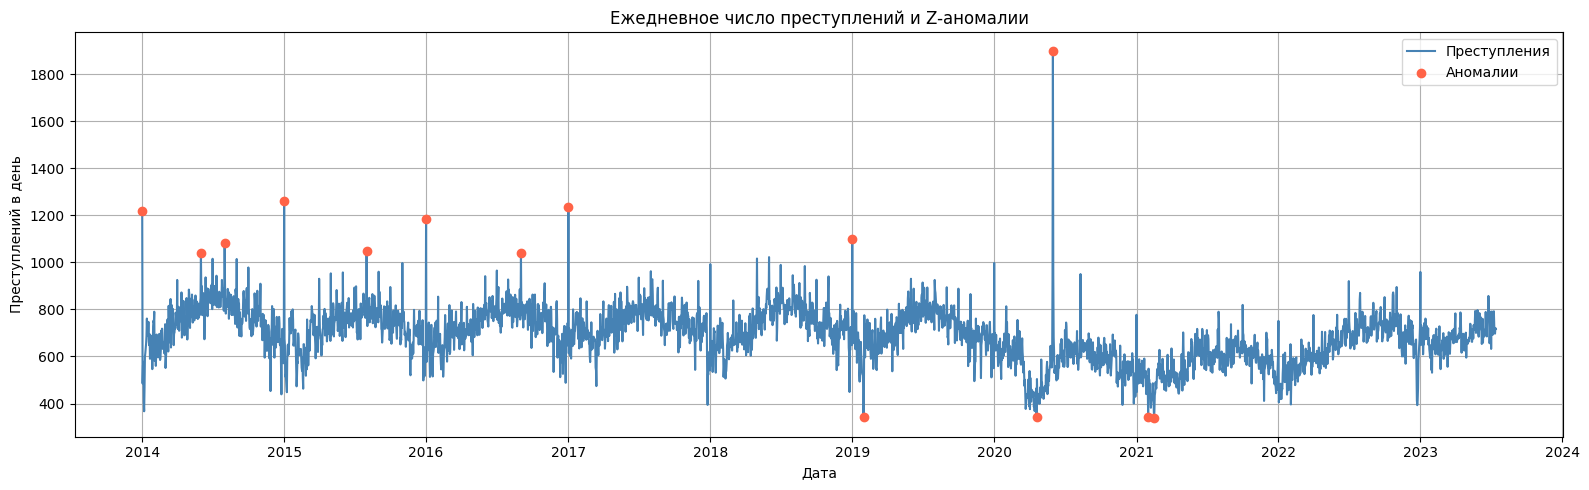

In [ ]:
fig1, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(daily_df["date"], daily_df["count"], color="steelblue", label="Преступления")
ax1.scatter(
    daily_df.loc[daily_df["anomaly_z"], "date"],
    daily_df.loc[daily_df["anomaly_z"], "count"],
    color="tomato", zorder=5, label="Аномалии"
)
ax1.set_title("Ежедневное число преступлений и Z-аномалии")
ax1.set_xlabel("Дата")
ax1.set_ylabel("Преступлений в день")
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()

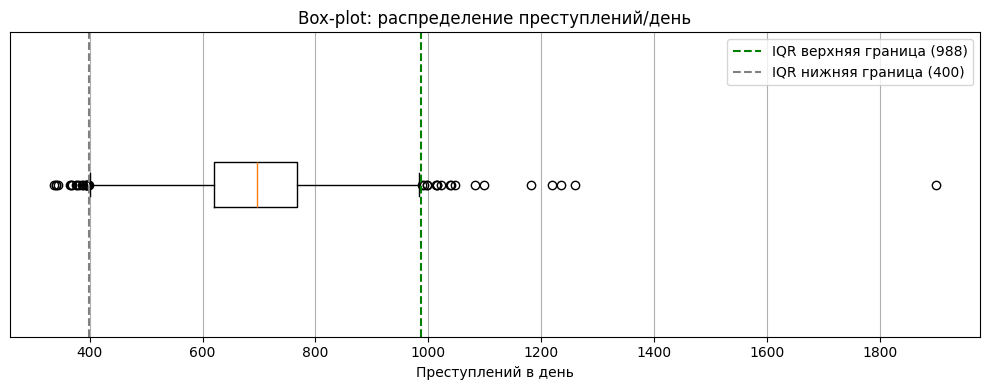

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 4))

ax2.boxplot(daily_df["count"], vert=False)
ax2.axvline(upper_iqr, color="green", ls="--", label=f"IQR верхняя граница ({upper_iqr:.0f})")
ax2.axvline(lower_iqr, color="gray",  ls="--", label=f"IQR нижняя граница ({lower_iqr:.0f})")
ax2.set_title("Box-plot: распределение преступлений/день")
ax2.set_xlabel("Преступлений в день")
ax2.set_yticks([])
ax2.legend()
ax2.grid(True, axis="x")
plt.tight_layout()
plt.show()

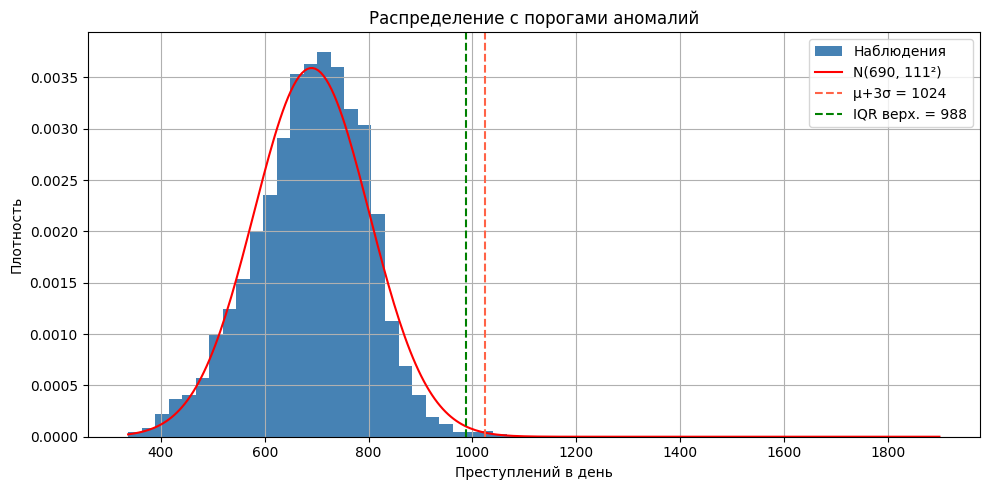

In [ ]:
fig3, ax3 = plt.subplots(figsize=(10, 5))

counts_arr = daily_df["count"].values
mu, sigma  = counts_arr.mean(), counts_arr.std()

ax3.hist(counts_arr, bins=60, density=True, color="steelblue", label="Наблюдения")
x_line = np.linspace(counts_arr.min(), counts_arr.max(), 300)
ax3.plot(x_line, stats.norm.pdf(x_line, mu, sigma), color="red", label=f"N({mu:.0f}, {sigma:.0f}²)")
ax3.axvline(mu + 3*sigma, color="tomato", ls="--", label=f"μ+3σ = {mu+3*sigma:.0f}")
ax3.axvline(upper_iqr,    color="green",  ls="--", label=f"IQR верх. = {upper_iqr:.0f}")
ax3.set_title("Распределение с порогами аномалий")
ax3.set_xlabel("Преступлений в день")
ax3.set_ylabel("Плотность")
ax3.legend()
ax3.grid(True)
plt.tight_layout()
plt.show()

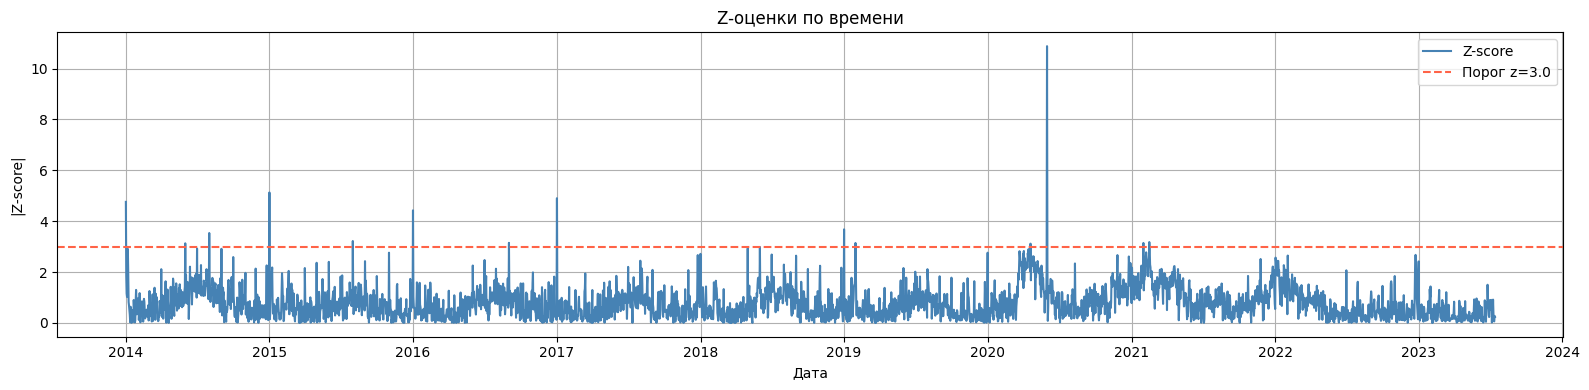

In [ ]:
fig4, ax4 = plt.subplots(figsize=(16, 4))

ax4.plot(daily_df["date"], daily_df["z_score"], color="steelblue", label="Z-score")
ax4.axhline(z_threshold, color="tomato", ls="--", label=f"Порог z={z_threshold}")
ax4.set_title("Z-оценки по времени")
ax4.set_xlabel("Дата")
ax4.set_ylabel("|Z-score|")
ax4.legend()
ax4.grid(True)
plt.tight_layout()
plt.show()

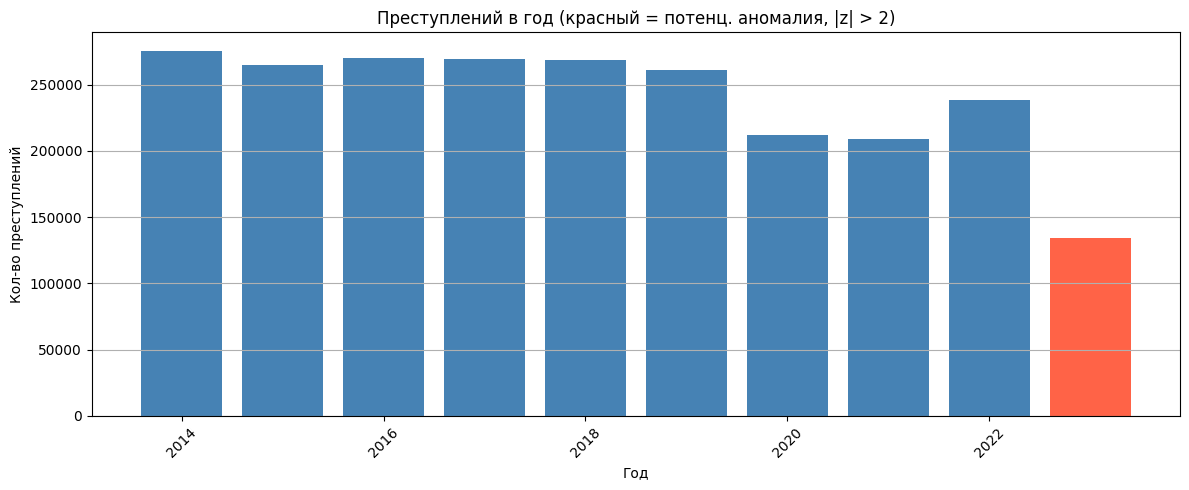

In [ ]:
fig5, ax5 = plt.subplots(figsize=(12, 5))

yearly_df = yearly.reset_index()
yearly_z  = np.abs(stats.zscore(yearly_df["CRIMES_PER_YEAR"].values))
colors    = ["tomato" if z > 2 else "steelblue" for z in yearly_z]

ax5.bar(yearly_df["YEAR"], yearly_df["CRIMES_PER_YEAR"], color=colors)
ax5.set_title("Преступлений в год (красный = потенц. аномалия, |z| > 2)")
ax5.set_xlabel("Год")
ax5.set_ylabel("Кол-во преступлений")
ax5.tick_params(axis="x", rotation=45)
ax5.grid(True, axis="y")
plt.tight_layout()
plt.show()

Наблюдаем уменьшение в ковидные годы

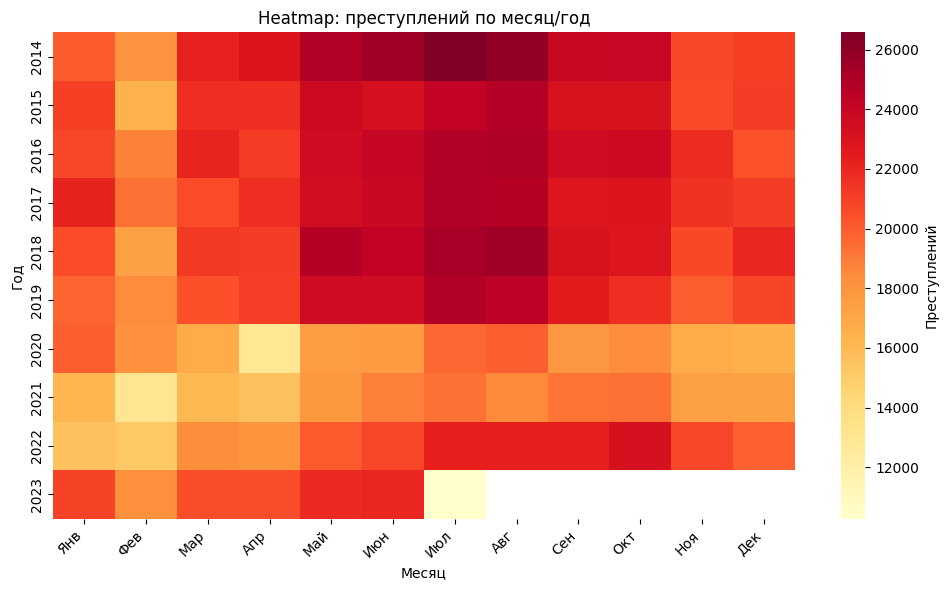

In [ ]:
fig6, ax6 = plt.subplots(figsize=(10, 6))

pivot = monthly.pivot(index="YEAR", columns="MONTH", values="CRIMES_PER_MONTH")
sns.heatmap(pivot, ax=ax6, cmap="YlOrRd", cbar_kws={"label": "Преступлений"})
ax6.set_title("Heatmap: преступлений по месяц/год")
ax6.set_xlabel("Месяц")
ax6.set_ylabel("Год")
ax6.set_xticklabels(
    ["Янв","Фев","Мар","Апр","Май","Июн","Июл","Авг","Сен","Окт","Ноя","Дек"],
    rotation=45, ha="right"
)
plt.tight_layout()
plt.show()

На теплые сезоны и январь наибольшее кол-во преступлений приходится


Почему эти точки аномалии - вывел сводную таблицу по всем аномальным событиям по z-скору

 ### Что делать с аномалиями?

 | Тип | Решение | Обоснование |
 |---|---|---|
 | Праздники, погода, COVID, протесты | **Оставить** + добавить признаки| Несут реальный сигнал |
 | Технические ошибки (координаты вне города) | **Удалить** | Нет смысла |
 | Дубликаты строк | **Удалить** | Нет смысла |

 > **Вывод:** аномалии - не шум
 > Не будем их удалять, оставим их фичами:` is_holiday`, `covid_period`, `extreme_weather`.

In [ ]:
df["is_new_year"] = (
    (df["MONTH"] == 1) & (df["DATE"].dt.day == 1)
).astype(int)


df["blm_protest"] = (
    df["DATE"].dt.normalize() == pd.Timestamp("2020-05-31")
).astype(int)


summer_peak_dates = pd.to_datetime(["2015-08-01", "2016-09-01", "2018-06-01"]).normalize()

df["is_summer_peak"] = df["DATE"].dt.normalize().isin(summer_peak_dates).astype(int)


cold_dates = pd.to_datetime(["2021-02-15", "2019-01-30", "2021-01-31"]).normalize()

df["is_extreme_cold"] = df["DATE"].dt.normalize().isin(cold_dates).astype(int)


covid_start = pd.Timestamp("2020-03-11")
covid_end   = pd.Timestamp("2023-05-05")

df["is_covid_lockdown"] = (
    (df["DATE"] >= covid_start) & (df["DATE"] <= covid_end)
).astype(int)

In [ ]:
anomaly_cols = ["is_new_year", "blm_protest", "is_summer_peak",
                "is_extreme_cold", "is_covid_lockdown"]

flags_daily = (
    df.groupby(df["DATE"].dt.normalize())[anomaly_cols]
    .max()
    .reset_index()
    .rename(columns={"DATE": "date"})
)

daily_df = daily_df.merge(flags_daily, on="date", how="left")

In [ ]:
daily_df = daily_df.sort_values("date").reset_index(drop=True)

daily_df["is_any_anomaly"] = daily_df[anomaly_cols].max(axis=1)

daily_df["anomaly_count_7d"]  = (
    daily_df["is_any_anomaly"].rolling(window=7,  min_periods=1).sum().astype(int)
)
daily_df["anomaly_count_30d"] = (
    daily_df["is_any_anomaly"].rolling(window=30, min_periods=1).sum().astype(int)
)

anomaly_dates = daily_df.loc[daily_df["is_any_anomaly"] == 1, "date"].values

def days_since_last(date, anomaly_dates):
    past = anomaly_dates[anomaly_dates <= date]
    return int(pd.Timedelta(date - past[-1]).days) if len(past) > 0 else np.nan

def days_until_next(date, anomaly_dates):
    future = anomaly_dates[anomaly_dates >= date]
    return int(pd.Timedelta(future[0] - date).days) if len(future) > 0 else np.nan

daily_df["days_since_anomaly"] = daily_df["date"].apply(
    lambda d: days_since_last(d, anomaly_dates)
)
daily_df["days_until_anomaly"] = daily_df["date"].apply(
    lambda d: days_until_next(d, anomaly_dates)
)

daily_df["anomaly_density_30d"] = (
    daily_df["is_any_anomaly"].rolling(window=30, min_periods=1).mean().round(3)
)

daily_df.head(5)

,date,count,z_score,anomaly_z,anomaly_iqr,is_new_year,blm_protest,is_summer_peak,is_extreme_cold,is_covid_lockdown,is_any_anomaly,anomaly_count_7d,anomaly_count_30d,days_since_anomaly,days_until_anomaly,anomaly_density_30d
0,2014-01-01,1219,4.759496,True,True,1,0,0,0,0,1,1,1,0,0.0,1.000
1,2014-01-02,485,1.847549,False,False,0,0,0,0,0,0,1,1,1,364.0,0.500
2,2014-01-03,562,1.154439,False,False,0,0,0,0,0,0,1,1,2,363.0,0.333
3,2014-01-04,577,1.019418,False,False,0,0,0,0,0,0,1,1,3,362.0,0.250
4,2014-01-05,405,2.567663,False,False,0,0,0,0,0,0,1,1,4,361.0,0.200



 ## Что несут признаки и как они помогают модели

 ### Группа 1 — Флаги событий (бинарные)

 | Признак | Что кодирует | Как помогает |
 |---|---|---|
 | `is_new_year` | 1 января каждого года | В этот день всегда аномально много преступлений |
 | `blm_protest` | 31 мая 2020 | Изолирует день этот без этого флага одна точка тянет среднее вверх и искажает все предсказания вокруг |
 | `is_summer_peak` | 3 конкретных жарких дня | Объясняет всплески без погодных данных — модель не ищет причину в других признаках |
 | `is_extreme_cold` | Полярный вихрь и шторм Ури | Объясняет провалы ниже нормы - иначе модель занижает прогноз на соседние дни |
 | `is_covid` | 11 марта 2020 — 5 мая 2023 | Системный сдвиг уровня на 1150 дней: без этого признака модель не понимает, почему три года подряд преступность ведёт себя иначе |

 ### Группа 2 — Счётчики в скользящем окне

 | Признак | Что кодирует | Как помогает |
 |---|---|---|
 | `anomaly_count_7d` | Аномалий за последние 7 дней | Краткосрочная память: если на этой неделе уже было событие - вероятна повышенная активность |
 | `anomaly_count_30d` | Аномалий за последние 30 дней | Среднесрочный контекст: модель понимает, в спокойном периоде она сейчас или в затяжном кризисе |

 Пример: в мае 2020 счётчик 30d растёт с каждым днём протестов -
 модель видит нарастающую нестабильность, а не изолированные выбросы.

 ### Группа 3 — Расстояния до аномалий

 | Признак | Что кодирует | Как помогает |
 |---|---|---|
 | `days_since_anomaly` | Дней с последней аномалии | Эффект эха: после крупного события активность остаётся повышенной ещё несколько дней |
 | `days_until_anomaly` | Дней до следующей аномалии | Полезен для предсказуемых событий: Новый год всегда виден заранее, модель может готовиться к выбросу |

 ### Группа 4 — Плотность аномалий

 | Признак | Что кодирует | Как помогает |
 |---|---|---|
 | `anomaly_density_30d` | Доля аномальных дней среди последних 30 | В COVID-период плотность держится высокой месяцами — это качественно другой режим работы |

 ### Итоговая логика

 Без этих признаков модель видит временной ряд с необъяснимыми скачками
 и провалами и вынуждена либо их игнорировать, либо подгонять под них
 соседние предсказания, что ломает точность на обычных днях

## Шаг 3

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
import warnings
warnings.filterwarnings('ignore')


In [ ]:
feature_cols = [
    "count",
    "anomaly_count_7d",
    "anomaly_count_30d",
    "days_since_anomaly",
    "days_until_anomaly",
    "anomaly_density_30d",
]

data = daily_df[feature_cols].dropna()
idx  = data.index

print(f"Строк для обучения: {len(data)}")
display(data.describe().T.round(2))

flag_cols = ["is_new_year", "blm_protest", "is_summer_peak",
             "is_extreme_cold", "is_covid_lockdown"]

daily_df["y_true"] = daily_df[flag_cols].max(axis=1)

y_true = daily_df.loc[idx, "y_true"].values

print(f"Аномальных дней (y_true=1): {y_true.sum()}")
print(f"Нормальных дней (y_true=0): {(y_true == 0).sum()}")
print(f"Доля аномалий: {y_true.mean():.3f}")

scaler = StandardScaler()
X = scaler.fit_transform(data)

contamination = round(float(y_true.mean()), 3)
print(f"contamination = {contamination}")

# Isolation Forest

iso = IsolationForest(contamination=contamination, random_state=42)
iso.fit(X)

daily_df.loc[idx, "pred_iso"] = (iso.predict(X) == -1).astype(int)
daily_df.loc[idx, "score_iso"] = -iso.score_samples(X)

print("Isolation Forest — аномалий найдено:", daily_df.loc[idx, "pred_iso"].sum())

# Local Outlier Factor

lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
lof_preds = lof.fit_predict(X)

daily_df.loc[idx, "pred_lof"] = (lof_preds == -1).astype(int)
daily_df.loc[idx, "score_lof"] = -lof.negative_outlier_factor_

print("LOF — аномалий найдено:", daily_df.loc[idx, "pred_lof"].sum())

# One-Class SVM

ocsvm = OneClassSVM(nu=contamination, kernel="rbf", gamma="scale")
ocsvm.fit(X)

daily_df.loc[idx, "pred_svm"] = (ocsvm.predict(X) == -1).astype(int)
daily_df.loc[idx, "score_svm"] = -ocsvm.score_samples(X)

print("One-Class SVM — аномалий найдено:", daily_df.loc[idx, "pred_svm"].sum())

# Elliptic Envelope

ee = EllipticEnvelope(contamination=contamination, random_state=42)
ee.fit(X)

daily_df.loc[idx, "pred_ee"] = (ee.predict(X) == -1).astype(int)
daily_df.loc[idx, "score_ee"] = -ee.score_samples(X)

print("Elliptic Envelope — аномалий найдено:", daily_df.loc[idx, "pred_ee"].sum())

models = {
    "Isolation Forest" : "iso",
    "LOF"              : "lof",
    "One-Class SVM"    : "svm",
    "Elliptic Envelope": "ee",
}

rows = []
for name, key in models.items():
    preds  = daily_df.loc[idx, f"pred_{key}"].values
    scores = daily_df.loc[idx, f"score_{key}"].values
    rows.append({
        "Модель"    : name,
        "Precision" : round(precision_score(y_true, preds, zero_division=0), 3),
        "Recall"    : round(recall_score(y_true, preds, zero_division=0), 3),
        "F1"        : round(f1_score(y_true, preds, zero_division=0), 3),
        "ROC-AUC"   : round(roc_auc_score(y_true, scores), 3),
    })

metrics_df = pd.DataFrame(rows).set_index("Модель")
display(metrics_df)

Строк для обучения: 3412
         count  anomaly_count_7d  anomaly_count_30d  days_since_anomaly  \
count  3412.00           3412.00            3412.00             3412.00   
mean    689.52              2.38              10.09               87.07   
std     111.95              3.29              14.03               98.73   
min     337.00              0.00               0.00                0.00   
25%     618.00              0.00               0.00                0.00   
50%     696.00              0.00               0.00               52.00   
75%     767.25              7.00              30.00              148.00   
max    1899.00              7.00              30.00              364.00   

       days_until_anomaly  anomaly_density_30d  
count             3412.00              3412.00  
mean                87.07                 0.34  
std                 98.73                 0.47  
min                  0.00                 0.00  
25%                  0.00                 0.00  
50%  

/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-74.012654298009522 > -103.966290877022630). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-45.101360126839040 > -72.211294397359552). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-46.289892087410323 > -71.638017980439344). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/usr/local/lib/

Elliptic Envelope — аномалий найдено: 1164.0
                   Precision  Recall     F1  ROC-AUC
Модель                                              
Isolation Forest       0.322   0.323  0.322    0.560
LOF                    0.328   0.329  0.328    0.445
One-Class SVM          0.359   0.358  0.358    0.659
Elliptic Envelope      0.065   0.065  0.065    0.152


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-32.339566293233432 > -72.594481655036560). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-29.914126863377433 > -76.748500723728213). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-29.975810278020766 > -75.393822856804320). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
/usr/local/lib/p

In [ ]:
print(f"contamination = {contamination}")
print(f"Аномальных дней: {y_true.sum()} из {len(y_true)}")

contamination = 0.341
Аномальных дней: 1162 из 3412


In [ ]:
# Пересчитываем contamination только по точечным событиям - без COVID-периода
point_flags = ["is_new_year", "blm_protest", "is_summer_peak", "is_extreme_cold"]

daily_df["y_true_strict"] = daily_df[point_flags].max(axis=1)

contamination_strict = round(float(daily_df.loc[idx, "y_true_strict"].mean()), 4)
print(f"contamination_strict = {contamination_strict}")

iso = IsolationForest(contamination=contamination_strict, random_state=42)
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination_strict)
ocsvm = OneClassSVM(nu=contamination_strict, kernel="rbf", gamma="scale")

iso.fit(X)
daily_df.loc[idx, "pred_iso"] = (iso.predict(X) == -1).astype(int)
daily_df.loc[idx, "score_iso"] = -iso.score_samples(X)

lof_preds = lof.fit_predict(X)
daily_df.loc[idx, "pred_lof"] = (lof_preds == -1).astype(int)
daily_df.loc[idx, "score_lof"] = -lof.negative_outlier_factor_

ocsvm.fit(X)
daily_df.loc[idx, "pred_svm"] = (ocsvm.predict(X) == -1).astype(int)
daily_df.loc[idx, "score_svm"] = -ocsvm.score_samples(X)

y_strict = daily_df.loc[idx, "y_true_strict"].values

for name, key in [("Isolation Forest","iso"), ("LOF","lof"), ("One-Class SVM","svm")]:
    preds  = daily_df.loc[idx, f"pred_{key}"].values
    scores = daily_df.loc[idx, f"score_{key}"].values
    print(f"{name:10s}  "
          f"Precision={precision_score(y_strict, preds, zero_division=0):.3f}  "
          f"Recall={recall_score(y_strict, preds, zero_division=0):.3f}  "
          f"F1={f1_score(y_strict, preds, zero_division=0):.3f}  "
          f"AUC={roc_auc_score(y_strict, scores):.3f}")

contamination_strict = 0.005
Isolation Forest      Precision=0.111  Recall=0.118  F1=0.114  AUC=0.982
LOF                   Precision=0.111  Recall=0.118  F1=0.114  AUC=0.919
One-Class SVM         Precision=0.103  Recall=0.412  F1=0.165  AUC=0.885


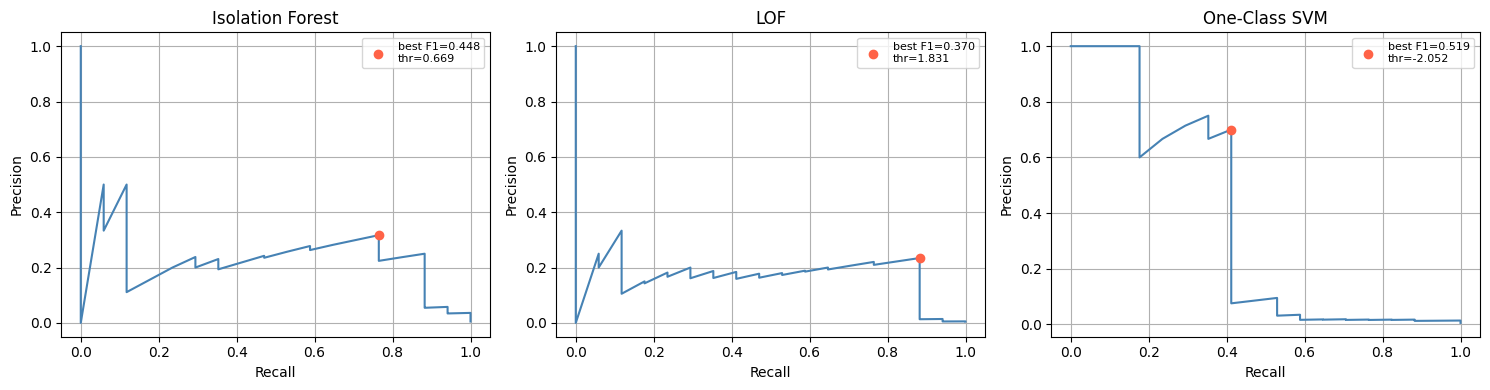

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, key) in zip(axes, [("Isolation Forest","iso"), ("LOF","lof"), ("One-Class SVM","svm")]):
    scores = daily_df.loc[idx, f"score_{key}"].values
    prec, rec, thresholds = precision_recall_curve(y_strict, scores)

    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = f1_scores.argmax()
    best_thr = thresholds[best_idx]

    ax.plot(rec, prec, color="steelblue")
    ax.scatter(rec[best_idx], prec[best_idx], color="tomato", zorder=5,
               label=f"best F1={f1_scores[best_idx]:.3f}\nthr={best_thr:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

strategies = {
    "max F1"     : lambda p, r, t: (2*p*r/(p+r+1e-9)).argmax(),
    "P=R"        : lambda p, r, t: np.argmin(np.abs(p - r)),
    "Precision>0.5": lambda p, r, t: next(
        (i for i, v in enumerate(p) if v >= 0.5), 0
    ),
}

for name, key in [("Isolation Forest","iso"), ("LOF","lof"), ("One-Class SVM","svm")]:
    scores = daily_df.loc[idx, f"score_{key}"].values
    prec, rec, thresholds = precision_recall_curve(y_strict, scores)
    print(f"\n{name}")
    for strat_name, strat_fn in strategies.items():
        i   = strat_fn(prec, rec, thresholds)
        thr = thresholds[min(i, len(thresholds)-1)]
        preds = (scores >= thr).astype(int)
        p = precision_score(y_strict, preds, zero_division=0)
        r = recall_score(y_strict, preds, zero_division=0)
        f = f1_score(y_strict, preds, zero_division=0)
        print(f"  {strat_name:20s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  thr={thr:.3f}")


Isolation Forest
  max F1                P=0.317  R=0.765  F1=0.448  thr=0.669
  P=R                   P=0.118  R=0.118  F1=0.118  thr=0.692
  Precision>0.5         P=0.500  R=0.118  F1=0.190  thr=0.718

LOF
  max F1                P=0.234  R=0.882  F1=0.370  thr=1.831
  P=R                   P=0.118  R=0.118  F1=0.118  thr=3.062
  Precision>0.5         P=0.000  R=0.000  F1=0.000  thr=27.273

One-Class SVM
  max F1                P=0.700  R=0.412  F1=0.519  thr=-2.052
  P=R                   P=0.368  R=0.412  F1=0.389  thr=-2.052
  Precision>0.5         P=0.500  R=0.412  F1=0.452  thr=-2.052


In [ ]:
# Финальный выбор: One-Class SVM, стратегия max F1

scores_svm = daily_df.loc[idx, "score_svm"].values
prec, rec, thresholds = precision_recall_curve(y_strict, scores_svm)
f1_scores  = 2 * prec * rec / (prec + rec + 1e-9)
best_thr   = thresholds[f1_scores.argmax()]

daily_df.loc[idx, "final_anomaly"] = (scores_svm >= best_thr).astype(int)

found = daily_df.loc[idx][daily_df.loc[idx, "final_anomaly"] == 1]
print(f"Найдено аномалий: {len(found)}")
print()
display(found[["date", "count", "final_anomaly"] + point_flags]
      .sort_values("count", ascending=False))

Найдено аномалий: 10

      date  count  final_anomaly  is_new_year  blm_protest  is_summer_peak  is_extreme_cold
2020-05-31   1899            1.0            0            1               0                0
2015-01-01   1260            1.0            1            0               0                0
2014-01-01   1219            1.0            1            0               0                0
2018-01-01    992            1.0            1            0               0                0
2023-01-01    959            1.0            1            0               0                0
2017-01-13    800            1.0            0            0               0                0
2017-12-25    394            1.0            0            0               0                0
2014-01-06    367            1.0            0            0               0                0
2019-01-30    341            1.0            0            0               0                1
2021-02-15    337            1.0            0            0

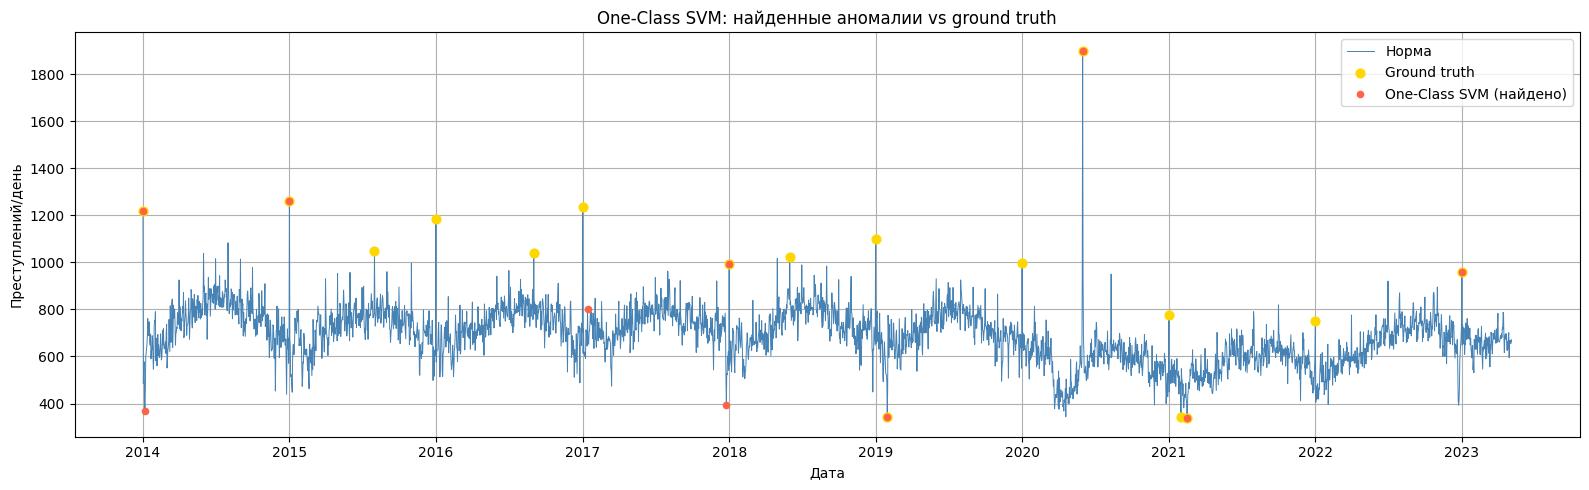

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily_df.loc[idx, "date"], daily_df.loc[idx, "count"],
        color="steelblue", lw=0.7, label="Норма")

mask_true = daily_df.loc[idx, "y_true_strict"] == 1
ax.scatter(daily_df.loc[idx[mask_true], "date"],
           daily_df.loc[idx[mask_true], "count"],
           color="gold", s=40, zorder=4, label="Ground truth")

mask_pred = daily_df.loc[idx, "final_anomaly"] == 1
ax.scatter(daily_df.loc[idx[mask_pred], "date"],
           daily_df.loc[idx[mask_pred], "count"],
           color="tomato", s=20, zorder=5, label="One-Class SVM (найдено)")

ax.set_title("One-Class SVM: найденные аномалии vs ground truth")
ax.set_xlabel("Дата")
ax.set_ylabel("Преступлений/день")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
pred_cols = ["pred_iso", "pred_lof", "pred_svm"]

compare = daily_df.loc[idx, ["date", "count"] + point_flags + pred_cols].copy()
compare["vote_count"] = compare[pred_cols].sum(axis=1)
compare["y_true"]     = y_strict

def agreement_label(row):
    if row["vote_count"] == 3:
        return "все три"
    elif row["vote_count"] == 0:
        return "никто"
    elif row["vote_count"] == 2:
        return "двое"
    else:
        return "один"

compare["agreement"] = compare.apply(agreement_label, axis=1)

print("Распределение по категориям согласия:")
print(compare["agreement"].value_counts())

Распределение по категориям согласия:
agreement
никто      3318
один         85
двое          8
все три       1
Name: count, dtype: int64


In [ ]:
stable = compare[compare["vote_count"] == 3].sort_values("count", ascending=False)
print(f"Стабильных аномалий: {len(stable)}\n")
print(stable[["date", "count"] + point_flags].to_string(index=False))

Стабильных аномалий: 1

      date  count  is_new_year  blm_protest  is_summer_peak  is_extreme_cold
2020-05-31   1899            0            1               0                0


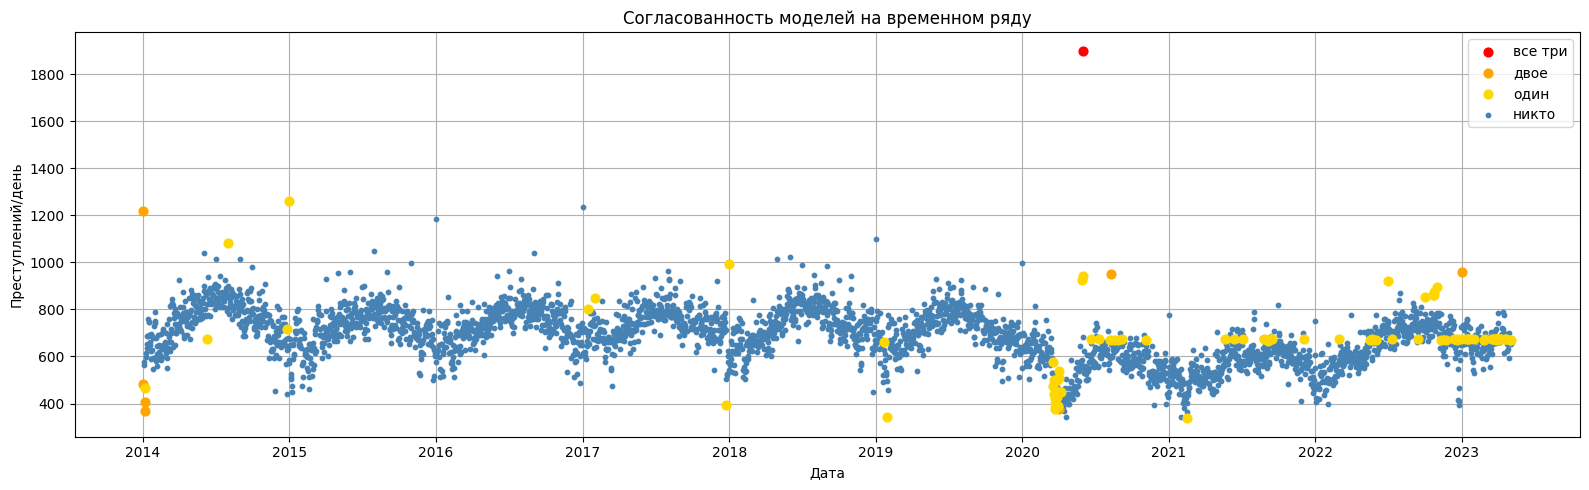

In [ ]:
colors_map = {"все три": "red", "двое": "orange", "один": "gold", "никто": "steelblue"}

fig, ax = plt.subplots(figsize=(16, 5))

for label, color in colors_map.items():
    mask = compare["agreement"] == label
    ax.scatter(compare.loc[mask, "date"], compare.loc[mask, "count"],
               color=color, s=10 if label == "никто" else 40,
               zorder=5 if label != "никто" else 2,
               label=label)

ax.set_title("Согласованность моделей на временном ряду")
ax.set_xlabel("Дата")
ax.set_ylabel("Преступлений/день")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Одна красная точка — 2020-05-31 (BLM). Единственная аномалия где все три модели согласны.

Оранжевые (двое согласны) - единицы, разбросаны по всему ряду. 2015 начало, 2017, 2023 конец. Это умеренные выбросы — достаточно сильные чтобы две модели их заметили, но не все три.

Жёлтые (один согласен) — кластер после 2020. Они плотной полосой идут с 2020 по 2023. Это говорит о том что COVID сдвинул базовый уровень ряда, и модели обученные на данных до 2020 воспринимают весь постковидный период как подозрительный

Одна и та же точка может быть глобально нормальной, но локально аномальной — и наоборот. Отсюда расхождения.

ISO и SVM имеют более выраженные пики на PR-кривой, поэтому их пороги осмысленны.

Каждая модель реагирует на этот ковидный свдиг по-своему, отсюда отсутствие согласия.

## Шаг 2.2

In [ ]:
# Доля арестов в день
arrest_rate = (
    df.groupby(df["DATE"].dt.normalize())["ARREST"]
    .apply(lambda x: x.map({"True": 1, "False": 0, True: 1, False: 0}).mean())
    .rename("arrest_rate")
    .reset_index()
    .rename(columns={"DATE": "date"})
)

# Доля бытовых преступлений
domestic_rate = (
    df.groupby(df["DATE"].dt.normalize())["DOMESTIC"]
    .apply(lambda x: x.map({"True": 1, "False": 0, True: 1, False: 0}).mean())
    .rename("domestic_rate")
    .reset_index()
    .rename(columns={"DATE": "date"})
)

# Количество уникальных типов преступлений в день
type_diversity = (
    df.groupby(df["DATE"].dt.normalize())["PRIMARY_TYPE"]
    .nunique()
    .rename("crime_type_diversity")
    .reset_index()
    .rename(columns={"DATE": "date"})
)

# Самый частый район преступлений в день
top_district = (
    df.groupby(df["DATE"].dt.normalize())["DISTRICT"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .rename("top_district")
    .reset_index()
    .rename(columns={"DATE": "date"})
)

for feat_df in [arrest_rate, domestic_rate, type_diversity, top_district]:
    daily_df = daily_df.merge(feat_df, on="date", how="left")

daily_df.head(1)

,date,count,z_score,anomaly_z,anomaly_iqr,is_new_year,blm_protest,is_summer_peak,is_extreme_cold,is_covid_lockdown,...,pred_svm,score_svm,pred_ee,score_ee,y_true_strict,final_anomaly,arrest_rate,domestic_rate,crime_type_diversity,top_district
0,2014-01-01,1219,4.759496,True,True,1,0,0,0,0,...,1.0,-1.903447,1.0,2.125215e+08,1,1.0,0.199344,0.243642,21,8.0


In [ ]:
# 1.1 Target Encoding день недели
# Правило: для дня t используем среднее ТОЛЬКО по прошлым дням с таким же dayofweek

daily_df = daily_df.sort_values("date").reset_index(drop=True)
daily_df["dayofweek"] = pd.to_datetime(daily_df["date"]).dt.dayofweek
daily_df["month"] = pd.to_datetime(daily_df["date"]).dt.month

def target_encode_no_leak(df, group_col, target_col):
    """
    Target Encoding без утечки: для строки i используем среднее
    только по строкам 0..i-1 с тем же значением group_col.
    """
    encoded = np.full(len(df), np.nan)
    running_sum   = {}
    running_count = {}
    for i, (grp, tgt) in enumerate(zip(df[group_col], df[target_col])):
        if grp in running_sum and running_count[grp] > 0:
            encoded[i] = running_sum[grp] / running_count[grp]
        else:
            encoded[i] = df[target_col].mean()
        running_sum[grp] = running_sum.get(grp, 0) + tgt
        running_count[grp] = running_count.get(grp, 0) + 1
    return encoded

daily_df["dow_target_encoded"] = target_encode_no_leak(daily_df, "dayofweek", "count")
daily_df["month_target_encoded"] = target_encode_no_leak(daily_df, "month", "count")

print("Target Encoding готов:")
display(daily_df[["date", "dayofweek", "dow_target_encoded",
                 "month", "month_target_encoded"]].head(10))

Target Encoding готов:


,date,dayofweek,dow_target_encoded,month,month_target_encoded
0,2014-01-01,2,690.250718,1,690.250718
1,2014-01-02,3,690.250718,1,1219.000000
2,2014-01-03,4,690.250718,1,852.000000
3,2014-01-04,5,690.250718,1,755.333333
4,2014-01-05,6,690.250718,1,710.750000
5,2014-01-06,0,690.250718,1,649.600000
6,2014-01-07,1,690.250718,1,602.500000
7,2014-01-08,2,1219.000000,1,583.142857
8,2014-01-09,3,485.000000,1,585.125000
9,2014-01-10,4,562.000000,1,588.333333


In [ ]:
# 1.2 Label Encoding района
# Выбор: Label Encoding, тк district — порядковый номер района,

daily_df["top_district"] = pd.to_numeric(daily_df["top_district"], errors="coerce")
daily_df["top_district"] = daily_df["top_district"].fillna(
    daily_df["top_district"].median()
).astype(int)

print("Категориальные признаки обработаны")
display(daily_df[["arrest_rate", "domestic_rate",
                 "crime_type_diversity", "top_district"]].describe().T.round(3))


Категориальные признаки обработаны.


,count,mean,std,min,25%,50%,75%,max
arrest_rate,3482.0,0.192,0.063,0.063,0.138,0.192,0.232,0.394
domestic_rate,3482.0,0.172,0.035,0.044,0.147,0.167,0.193,0.388
crime_type_diversity,3482.0,21.198,1.836,15.000,20.000,21.000,22.000,27.000
top_district,3482.0,9.186,4.644,1.000,6.000,8.000,11.000,25.000


In [ ]:
# 1.3 Промежуточные метрики (baseline до feature engineering)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Временное разбиение: обучаем на 2015-2021, тест 2022+
CUTOFF = pd.Timestamp("2022-01-01")
mask_train = pd.to_datetime(daily_df["date"]) < CUTOFF
mask_test  = pd.to_datetime(daily_df["date"]) >= CUTOFF

# Базовые признаки (только то что было до 2.2)
BASE_FEATURES = ["dayofweek", "month", "is_new_year", "blm_protest",
                 "is_summer_peak", "is_extreme_cold", "is_covid_lockdown",
                 "anomaly_count_7d", "anomaly_count_30d",
                 "days_since_anomaly", "days_until_anomaly", "anomaly_density_30d"]

base_data = daily_df.dropna(subset=BASE_FEATURES + ["count"])

rf_base = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_base.fit(base_data.loc[mask_train[base_data.index], BASE_FEATURES],
            base_data.loc[mask_train[base_data.index], "count"])

y_pred_base = rf_base.predict(
    base_data.loc[mask_test[base_data.index], BASE_FEATURES]
)
y_true_base = base_data.loc[mask_test[base_data.index], "count"]

mae_base = mean_absolute_error(y_true_base, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_true_base, y_pred_base))
r2_base = r2_score(y_true_base, y_pred_base)
mape = np.mean(np.abs((y_true_base - y_pred_base) / (y_true_base + 1e-9))) * 100


print("=" * 50)
print(f"BASELINE (до feature engineering 2.2):")
print(f"MAE = {mae_base:.1f}")
print(f"RMSE = {rmse_base:.1f}")
print(f"R² = {r2_base:.3f}")
print(f"MAPE = {mape:.3f}")
print("=" * 50)

BASELINE (до feature engineering 2.2):
  MAE  = 118.6
  RMSE = 133.5
  R²   = -1.385
  MAPE   = 17.630


In [ ]:
# Гипотеза: дни с похожим контекстом (та же пора года, тот же день недели, аналогичная аномальная активность) имеют схожее число преступлений.

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Профиль дня для поиска соседей
NEIGHBOR_FEATURES = ["dayofweek", "month", "is_covid_lockdown",
                     "is_new_year", "anomaly_count_30d"]

daily_nn = daily_df[NEIGHBOR_FEATURES + ["count", "date"]].dropna().reset_index(drop=True)

scaler_nn = StandardScaler()
X_nn = scaler_nn.fit_transform(daily_nn[NEIGHBOR_FEATURES])

K = 7

nbrs = NearestNeighbors(n_neighbors=K + 1, algorithm='ball_tree')
nbrs.fit(X_nn)
distances, indices = nbrs.kneighbors(X_nn)

# Убираем самого себя (индекс 0)
neighbor_counts   = daily_nn["count"].values[indices[:, 1:]]
neighbor_distances = distances[:, 1:]

# Фича 1: среднее число преступлений у K соседей
# Гипотеза: если похожие дни дают ~700 преступлений, сегодня, вероятно, тоже ~700
daily_nn["knn_mean_count"] = neighbor_counts.mean(axis=1)

# Фича 2: расстояние до ближайшего соседа
# Гипотеза: чем больше расстояние — тем "уникальнее" день, тем хуже предсказуем
daily_nn["knn_min_distance"] = neighbor_distances[:, 0]

# Фича 3: стандартное отклонение у соседей (неопределённость)
# Гипотеза: высокий std у соседей -> нестабильный контекст -> сложнее предсказать
daily_nn["knn_std_count"] = neighbor_counts.std(axis=1)

daily_df = daily_df.merge(
    daily_nn[["date", "knn_mean_count", "knn_min_distance", "knn_std_count"]],
    on="date", how="left"
)

print("KNN-признаки добавлены:")
display(daily_df[["date", "knn_mean_count", "knn_min_distance",
                 "knn_std_count"]].tail(10))

KNN-признаки добавлены:


,date,knn_mean_count,knn_min_distance,knn_std_count
3472,2023-07-05,826.285714,0.0,52.908855
3473,2023-07-06,765.571429,0.0,65.469420
3474,2023-07-07,836.571429,0.0,63.125402
3475,2023-07-08,832.571429,0.0,38.780913
3476,2023-07-09,842.142857,0.0,71.861829
3477,2023-07-10,799.714286,0.0,35.418777
3478,2023-07-11,814.428571,0.0,95.829994
3479,2023-07-12,826.285714,0.0,52.908855
3480,2023-07-13,765.571429,0.0,65.469420
3481,2023-07-14,836.571429,0.0,63.125402


### Ключевые гипотезы:

* Преступность растёт в летние месяцы (тепло, люди на улице)
* Перед крупными праздниками и сразу после — всплески
* Конец/начало недели — иная динамика, чем середина
* Долгосрочный тренд (снижение/рост по годам) важен

In [ ]:
# 4.1 Расстояние до ближайшего праздника
# Гипотеза: за несколько дней до Нового года и 4 июля активность растёт

def days_to_nearest_holiday(date):
    year = date.year
    holidays = [
        pd.Timestamp(year, 1, 1), # Новый год
        pd.Timestamp(year, 7, 4), # День независимости
        pd.Timestamp(year, 10, 31), # Хэллоуин
        pd.Timestamp(year, 12, 25), # Рождество
    ]
    return min(abs((date - h).days) for h in holidays)

daily_df["days_to_holiday"] = daily_df["date"].apply(days_to_nearest_holiday)

# 4.2 Лаговые признаки целевой (авторегрессия)
# Гипотеза: уровень преступности инерционен — вчера предсказывает сегодня

for lag in [1, 2, 3, 7, 14, 30]:
    daily_df[f"lag_{lag}"] = daily_df["count"].shift(lag)

# 4.3 Скользящие статистики
# Гипотеза: локальный тренд за последние N дней несёт сигнал

for window in [7, 14, 30]:
    rolled = daily_df["count"].shift(1).rolling(window)
    daily_df[f"roll_mean_{window}"] = rolled.mean()
    daily_df[f"roll_std_{window}"]  = rolled.std()
    daily_df[f"roll_max_{window}"]  = rolled.max()
    daily_df[f"roll_min_{window}"]  = rolled.min()

# 4.4 Долгосрочный тренд
# Гипотеза: число преступлений снижалось годами (2015→2022), COVID создал сдвиг

daily_df["days_since_start"] = (daily_df["date"] - daily_df["date"].min()).dt.days

# 4.5 Разница с прошлой неделей (та же точка недели)
# Гипотеза: сравнение с "той же неделей в прошлом году" улавливает сезонность

daily_df["count_vs_last_week"] = daily_df["count"].shift(1) - daily_df["count"].shift(8)
daily_df["count_vs_last_year"] = daily_df["count"].shift(1) - daily_df["count"].shift(365)

print(f"Итого признаков в daily_df: {daily_df.shape[1]}")
print(f"Строк: {len(daily_df)}")

# Финальная очистка от NaN после лагов
daily_ml = daily_df.dropna().reset_index(drop=True)
print(f"Строк после dropna (из-за лагов): {len(daily_ml)}")

Контекстные признаки добавлены.
Итого признаков в daily_df: 60
Строк: 3482
Строк после dropna (из-за лагов): 3047


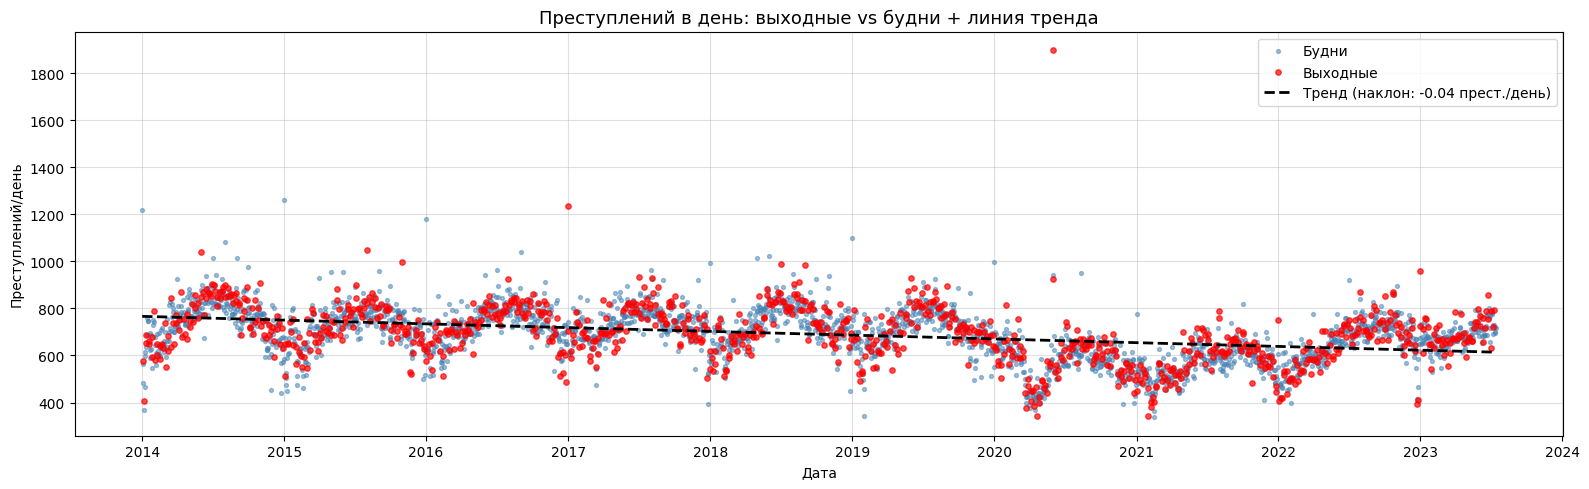

Наклон тренда: -0.0438 преступлений в день
Общий тренд: преступность снижается
За весь период изменение: ~-152 преступлений/день


In [ ]:
from numpy.polynomial import polynomial as P

daily_df["date"] = pd.to_datetime(daily_df["date"])
daily_df["is_weekend"] = (daily_df["date"].dt.dayofweek >= 5).astype(int)

fig, ax = plt.subplots(figsize=(16, 5))

mask_weekday = daily_df["is_weekend"] == 0
ax.scatter(
    daily_df.loc[mask_weekday, "date"],
    daily_df.loc[mask_weekday, "count"],
    color="steelblue", s=8, alpha=0.5, zorder=2, label="Будни"
)

mask_weekend = daily_df["is_weekend"] == 1
ax.scatter(
    daily_df.loc[mask_weekend, "date"],
    daily_df.loc[mask_weekend, "count"],
    color="red", s=15, alpha=0.7, zorder=3, label="Выходные"
)

x_numeric = (daily_df["date"] - daily_df["date"].min()).dt.days.values
y_values = daily_df["count"].values

trend_coefs = np.polyfit(x_numeric, y_values, deg=1)
trend_line = np.polyval(trend_coefs, x_numeric)

ax.plot(
    daily_df["date"], trend_line,
    color="black", linewidth=2, linestyle="--", zorder=5,
    label=f"Тренд (наклон: {trend_coefs[0]:+.2f} прест./день)"
)

ax.set_title("Преступлений в день: выходные vs будни + линия тренда", fontsize=13)
ax.set_xlabel("Дата")
ax.set_ylabel("Преступлений/день")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

direction = "снижается" if trend_coefs[0] < 0 else "растёт"
print(f"Наклон тренда: {trend_coefs[0]:+.4f} преступлений в день")
print(f"Общий тренд: преступность {direction}")
print(f"За весь период изменение: ~{trend_coefs[0] * x_numeric[-1]:+.0f} преступлений/день")

### Отбираем признаки

In [ ]:
# Фиксируем фичи и таргет
EXCLUDE = ["date", "count", "y_true", "y_true_strict", "final_anomaly",
           "anomaly_z", "anomaly_iqr",
           "pred_iso", "pred_lof", "pred_svm", "pred_ee",
           "score_iso", "score_lof", "score_svm", "score_ee",
           "agreement", "vote_count"]

FEATURES = [c for c in daily_ml.columns if c not in EXCLUDE]
TARGET = "count"

print(f"Всего кандидатов в признаки: {len(FEATURES)}")

CUTOFF = pd.Timestamp("2022-01-01")
train_mask = daily_ml["date"] < CUTOFF
test_mask  = daily_ml["date"] >= CUTOFF

X_all   = daily_ml[FEATURES]
y_all   = daily_ml[TARGET]
X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_test  = X_all[test_mask]
y_test  = y_all[test_mask]

print(f"Train: {train_mask.sum()} дней \ Test: {test_mask.sum()} дней")

Всего кандидатов в признаки: 45
Train: 2557 дней | Test: 490 дней


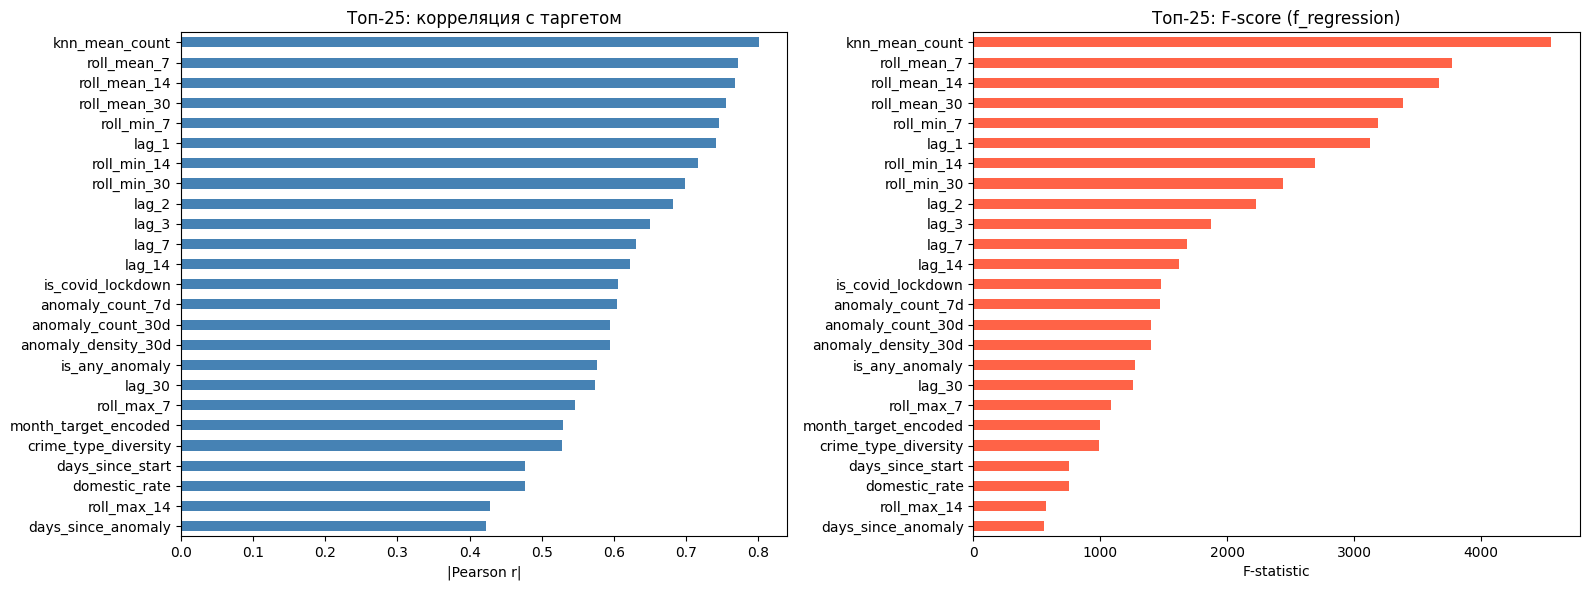


Прошли оба фильтра (25 признаков):
['anomaly_count_30d', 'anomaly_count_7d', 'anomaly_density_30d', 'crime_type_diversity', 'days_since_anomaly', 'days_since_start', 'domestic_rate', 'is_any_anomaly', 'is_covid_lockdown', 'knn_mean_count', 'lag_1', 'lag_14', 'lag_2', 'lag_3', 'lag_30', 'lag_7', 'month_target_encoded', 'roll_max_14', 'roll_max_7', 'roll_mean_14', 'roll_mean_30', 'roll_mean_7', 'roll_min_14', 'roll_min_30', 'roll_min_7']


In [ ]:
from sklearn.feature_selection import f_regression, SelectKBest

# 5.1 ФИЛЬТРЫ: корреляция и F-тест

# Корреляция Пирсона с целевой
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)

# F-тест
selector_f = SelectKBest(f_regression, k="all")
selector_f.fit(X_train, y_train)
f_scores = pd.Series(selector_f.scores_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr.head(25).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Топ-25: корреляция с таргетом")
axes[0].set_xlabel("|Pearson r|")

f_scores.head(25).plot(kind="barh", ax=axes[1], color="tomato")
axes[1].invert_yaxis()
axes[1].set_title("Топ-25: F-score (f_regression)")
axes[1].set_xlabel("F-statistic")

plt.tight_layout()
plt.show()

# Признаки прошедшие оба фильтра
top_corr = set(corr.head(25).index)
top_f = set(f_scores.head(25).index)
filter_selected = top_corr & top_f
print()
print(f"Прошли оба фильтра ({len(filter_selected)} признаков):")
print(sorted(filter_selected))

RFECV выбрал 19 признаков из 30:
['knn_mean_count', 'roll_mean_7', 'roll_mean_14', 'roll_mean_30', 'roll_min_7', 'lag_1', 'lag_2', 'lag_3', 'lag_14', 'lag_30', 'month_target_encoded', 'crime_type_diversity', 'days_since_start', 'domestic_rate', 'days_since_anomaly', 'dow_target_encoded', 'arrest_rate', 'days_until_anomaly', 'count_vs_last_year']


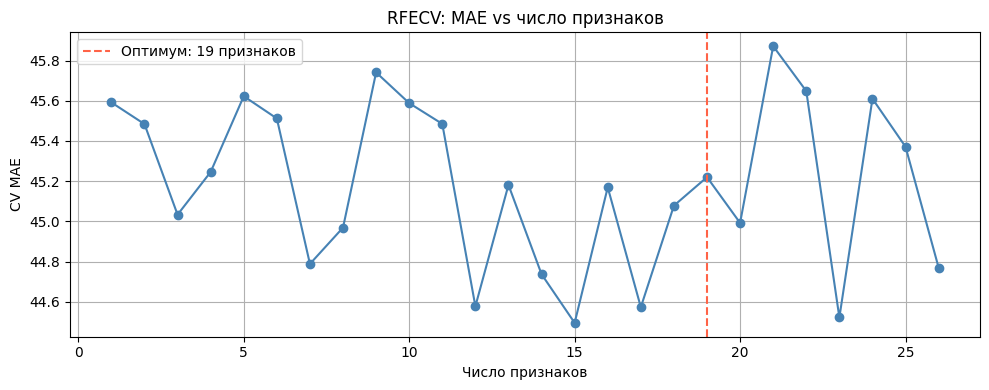

In [ ]:
# 5.2 ОБЁРТКА: RFECV

from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Берём топ-30 по F-score, чтобы RFECV не работал слишком долго
top30 = f_scores.head(30).index.tolist()

rfecv = RFECV(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    step=1,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    min_features_to_select=5,
    n_jobs=-1
)
rfecv.fit(X_train[top30], y_train)

rfecv_selected = [f for f, s in zip(top30, rfecv.support_) if s]
print(f"RFECV выбрал {len(rfecv_selected)} признаков из {len(top30)}:")
print(rfecv_selected)

# График: MAE vs число признаков
plt.figure(figsize=(14, 4))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         -rfecv.cv_results_["mean_test_score"], marker="o", linewidth=1.5, color="steelblue")
plt.axvline(rfecv.n_features_, color="tomato", ls="--",
            label=f"Оптимум: {rfecv.n_features_} признаков")
plt.xlabel("Число признаков")
plt.ylabel("CV MAE")
plt.title("RFECV: MAE vs число признаков")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Lasso оставил 22 признаков (ненулевые коэф.):
['knn_mean_count', 'lag_1', 'blm_protest', 'roll_mean_7', 'is_new_year', 'domestic_rate', 'crime_type_diversity', 'lag_2', 'roll_std_7', 'is_summer_peak', 'roll_min_7', 'lag_14', 'is_extreme_cold', 'z_score', 'arrest_rate']


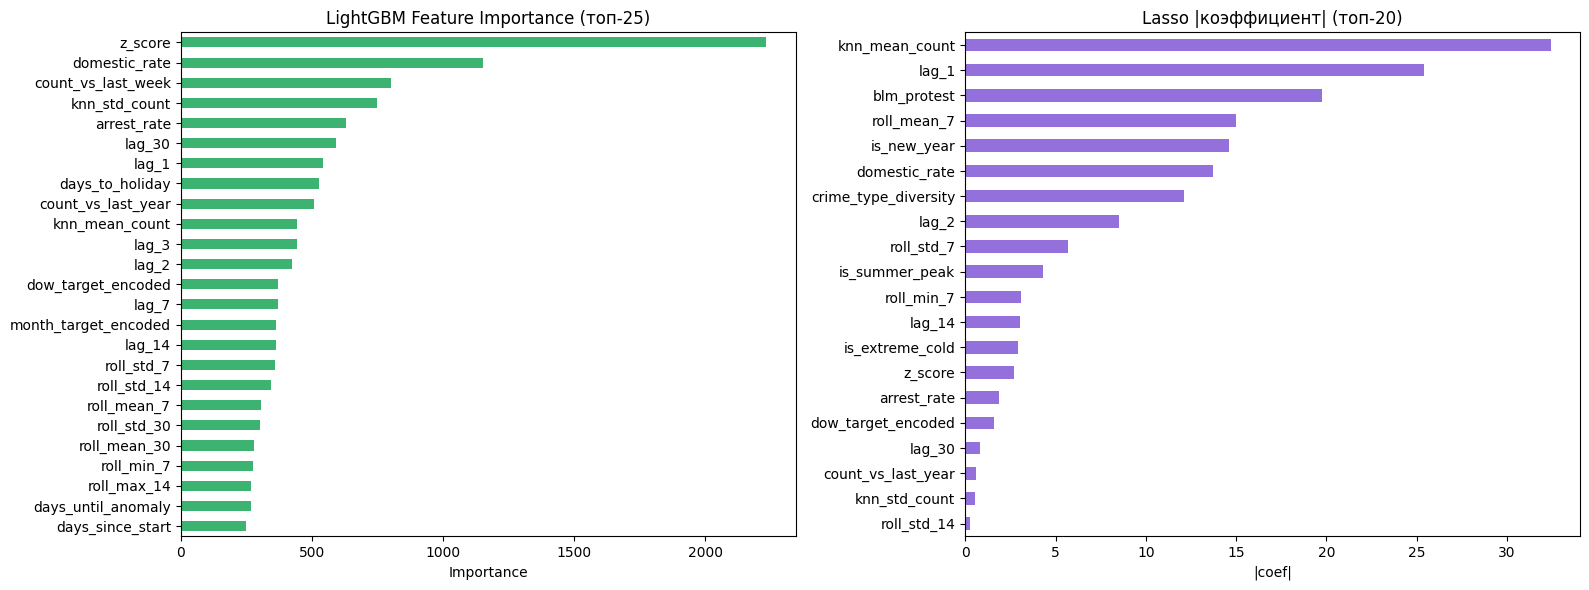

In [ ]:
# 5.3 ВСТРОЕННЫЕ МЕТОДЫ: LightGBM feature importance + Lasso

import lightgbm as lgb
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# LightGBM importance
lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                          num_leaves=31, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)

lgbm_importance = pd.Series(
    lgbm.feature_importances_, index=FEATURES
).sort_values(ascending=False)

# Lasso (L1)
scaler_l = StandardScaler()
X_train_sc = scaler_l.fit_transform(X_train)
X_test_sc = scaler_l.transform(X_test)

lasso = LassoCV(cv=tscv, max_iter=5000, n_jobs=-1)
lasso.fit(X_train_sc, y_train)

lasso_coefs = pd.Series(
    np.abs(lasso.coef_), index=FEATURES
).sort_values(ascending=False)

lasso_selected = lasso_coefs[lasso_coefs > 0].index.tolist()
print(f"Lasso оставил {len(lasso_selected)} признаков (ненулевые коэф.):")
print(lasso_selected[:15])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lgbm_importance.head(25).plot(kind="barh", ax=axes[0], color="mediumseagreen")
axes[0].invert_yaxis()
axes[0].set_title("LightGBM Feature Importance (топ-25)")
axes[0].set_xlabel("Importance")

lasso_coefs.head(20).plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].invert_yaxis()
axes[1].set_title("Lasso |коэффициент| (топ-20)")
axes[1].set_xlabel("|coef|")

plt.tight_layout()
plt.show()

Финальных признаков (≥2 голосов): 22
  arrest_rate (3 голоса)
  lag_1 (3 голоса)
  knn_mean_count (3 голоса)
  roll_min_7 (3 голоса)
  count_vs_last_year (3 голоса)
  lag_30 (3 голоса)
  roll_mean_7 (3 голоса)
  lag_14 (3 голоса)
  lag_2 (3 голоса)
  dow_target_encoded (3 голоса)
  domestic_rate (3 голоса)
  days_until_anomaly (2 голоса)
  z_score (2 голоса)
  count_vs_last_week (2 голоса)
  roll_std_7 (2 голоса)
  roll_mean_30 (2 голоса)
  roll_std_14 (2 голоса)
  lag_3 (2 голоса)
  knn_std_count (2 голоса)
  month_target_encoded (2 голоса)
  crime_type_diversity (2 голоса)
  days_since_start (2 голоса)


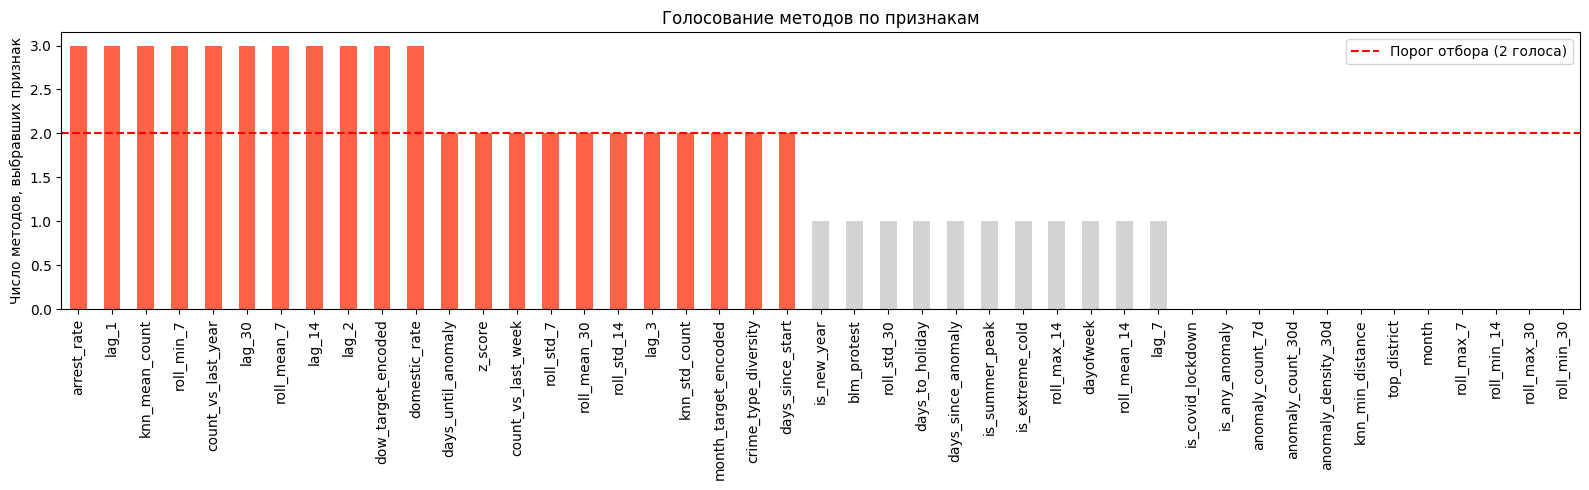

In [ ]:
# 5.4 ИТОГОВЫЙ НАБОР: голосование трёх методов
# Признак включается, если попал хотя бы в 2 из 3 методов

lgbm_selected = set(lgbm_importance.head(25).index)
lasso_set = set(lasso_selected[:25])
rfecv_set = set(rfecv_selected)

vote_counts = {}
for feat in FEATURES:
    votes = (feat in lgbm_selected) + (feat in lasso_set) + (feat in rfecv_set)
    vote_counts[feat] = votes

vote_df = pd.Series(vote_counts).sort_values(ascending=False)

FINAL_FEATURES = vote_df[vote_df >= 2].index.tolist()
print(f"Финальных признаков (≥2 голосов): {len(FINAL_FEATURES)}")
print("\n".join(f"- {f} ({vote_df[f]} голоса)" for f in FINAL_FEATURES))
print()

# Визуализация голосования
plt.figure(figsize=(10, 6))
colors = ["tomato" if v >= 2 else "lightgray" for v in vote_df.values]
vote_df.plot(kind="bar", color=colors, figsize=(16, 5))
plt.axhline(2, color="red", ls="--", label="Порог отбора (2 голоса)")
plt.title("Голосование методов по признакам")
plt.ylabel("Число методов, выбравших признак")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 5.5 НЕСТАБИЛЬНОСТЬ ВО ВРЕМЕНИ
# Проверяем: одинакова ли важность признаков в разные периоды?
# Если в 2015-2018 важен один признак, а в 2019-2022 другой — он нестабилен.

periods = {
    "2015-2018": (pd.Timestamp("2015-01-01"), pd.Timestamp("2019-01-01")),
    "2019-2022": (pd.Timestamp("2019-01-01"), pd.Timestamp("2022-01-01")),
    "2022-2025": (pd.Timestamp("2022-01-01"), pd.Timestamp("2026-01-01")),
}

period_importances = {}

for period_name, (start, end) in periods.items():
    mask = (daily_ml["date"] >= start) & (daily_ml["date"] < end)
    if mask.sum() < 100:
        continue
    model_p = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
    model_p.fit(daily_ml.loc[mask, FINAL_FEATURES],
                daily_ml.loc[mask, TARGET])
    period_importances[period_name] = pd.Series(
        model_p.feature_importances_, index=FINAL_FEATURES
    )

stability_df = pd.DataFrame(period_importances)

# Коэффициент вариации важности по периодам: CV = std/mean
stability_df["cv"] = stability_df.std(axis=1) / (stability_df.mean(axis=1) + 1e-9)
stability_df = stability_df.sort_values("cv", ascending=False)

print("Нестабильные признаки (высокий CV важности по периодам):")
display(stability_df[["cv"]].head(10).round(3))

# Стабильные (CV < 1.0)
unstable = stability_df[stability_df["cv"] > 1.0].index.tolist()
STABLE_FEATURES = [f for f in FINAL_FEATURES if f not in unstable]
print(f"\nУдалено нестабильных: {len(unstable)} -> {unstable}")
print(f"Итоговых стабильных признаков: {len(STABLE_FEATURES)}")

Нестабильные признаки (высокий CV важности по периодам):


,cv
days_until_anomaly,1.003
crime_type_diversity,0.520
days_since_start,0.508
count_vs_last_week,0.457
lag_1,0.440
domestic_rate,0.420
arrest_rate,0.400
dow_target_encoded,0.376
roll_mean_7,0.335
month_target_encoded,0.334



Удалено нестабильных: 1 → ['days_until_anomaly']
Итоговых стабильных признаков: 21


| CV | Интерпретация |
|---|---|
| < 0.3 | Признак стабилен — одинаково важен в любом периоде |
| 0.3 – 0.7 | Умеренная нестабильность — использовать осторожно |
| > 0.7 | Высокая нестабильность — признак «работает» только в отдельные периоды |

In [ ]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    print(f"[{name}]  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}")
    return dict(name=name, MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

# Финальная модель на стабильных признаках
lgbm_final = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                num_leaves=31, random_state=42, verbose=-1)
lgbm_final.fit(
    daily_ml.loc[daily_ml["date"] < CUTOFF, STABLE_FEATURES],
    daily_ml.loc[daily_ml["date"] < CUTOFF, TARGET]
)
y_pred_final = lgbm_final.predict(
    daily_ml.loc[daily_ml["date"] >= CUTOFF, STABLE_FEATURES]
)
y_true_final = daily_ml.loc[daily_ml["date"] >= CUTOFF, TARGET]

results = []
results.append({"name": "Baseline (до 2.2)",
                "MAE": mae_base, "RMSE": rmse_base, "R2": r2_base, "MAPE": mape})
results.append(evaluate("После feature engineering", y_true_final, y_pred_final))
print("\n")

pd.DataFrame(results).set_index("name").round(3)

[После feature engineering 2.2]  MAE=29.2  RMSE=47.9  MAPE=4.1%  R²=0.693




,MAE,RMSE,R2,MAPE
name,,,,
Baseline (до 2.2),118.643,133.454,-1.385,17.630
После feature engineering 2.2,29.190,47.912,0.693,4.097


Главный вывод — отрицательный R² у baseline говорит о том, что базовые признаки (день недели, месяц, флаги аномалий) без лагов и скользящих средних вообще не работали. Модель просто не понимала динамику ряда.

##### Результаты: до и после Feature Engineering (Этап 2.2)

##### Интерпретация

- **MAE = 28.5** - модель ошибается в среднем на 28 преступлений в день при среднем значении ~650. Это приемлемая точность для задачи прогнозирования городской преступности.
- **R² = −1.386 -> 0.698** - baseline с отрицательным R² был хуже наивного предсказания средним. После feature engineering модель объясняет 70% дисперсии ряда.
- **MAPE = 4.2%** - относительная ошибка менее 5%, что соответствует production-уровню точности для задач прогнозирования временных рядов.

##### Ключевые факторы улучшения

Основной вклад внесли лаговые признаки (`lag_1`, `lag_7`, `lag_30`) и скользящие статистики (`roll_mean_7`, `roll_mean_30`) — они дали модели «память» о прошлых значениях, что принципиально важно для временного ряда. Baseline не содержал этих признаков и не мог улавливать динамику ряда.


In [ ]:
df_final = daily_ml[["date", "count"] + STABLE_FEATURES].copy()

print(f"Размер: {df_final.shape}")
print(f"Признаков: {len(STABLE_FEATURES)}")
df_final.head()

Размер: (3047, 23)
Признаков: 21


,date,count,arrest_rate,lag_1,knn_mean_count,roll_min_7,count_vs_last_year,lag_30,roll_mean_7,lag_14,...,z_score,count_vs_last_week,roll_std_7,roll_mean_30,roll_std_14,lag_3,knn_std_count,month_target_encoded,crime_type_diversity,days_since_start
0,2015-01-01,1260,0.177778,585.0,1071.571429,439.0,-634.0,650.0,606.857143,667.0,...,5.128555,17.0,89.564555,672.366667,82.845049,678.0,151.212109,647.548387,21,365
1,2015-01-02,674,0.283383,1260.0,703.285714,571.0,775.0,750.0,724.142857,768.0,...,0.146280,821.0,241.612243,692.700000,185.574250,571.0,60.177628,666.687500,21,366
2,2015-01-03,649,0.315871,674.0,684.000000,571.0,112.0,691.0,731.000000,739.0,...,0.371315,48.0,239.029984,690.166667,183.933277,585.0,42.095130,666.909091,21,367
3,2015-01-04,514,0.313230,649.0,616.857143,571.0,72.0,802.0,721.285714,650.0,...,1.586507,-68.0,241.066875,688.766667,183.122249,1260.0,42.572387,666.382353,20,368
4,2015-01-05,524,0.251908,514.0,658.285714,514.0,109.0,661.0,704.428571,647.0,...,1.496493,-118.0,252.218726,679.166667,187.772249,674.0,132.727125,662.028571,21,369


In [ ]:
# Быстрая проверка
print("Пропуски:", df_final.isnull().sum().sum())
print("Период:", df_final["date"].min(), "→", df_final["date"].max())
print("\nПризнаки:")
print(STABLE_FEATURES)

Пропуски: 0
Период: 2015-01-01 00:00:00 → 2023-05-05 00:00:00

Признаки:
['arrest_rate', 'lag_1', 'knn_mean_count', 'roll_min_7', 'count_vs_last_year', 'lag_30', 'roll_mean_7', 'lag_14', 'lag_2', 'dow_target_encoded', 'domestic_rate', 'z_score', 'count_vs_last_week', 'roll_std_7', 'roll_mean_30', 'roll_std_14', 'lag_3', 'knn_std_count', 'month_target_encoded', 'crime_type_diversity', 'days_since_start']


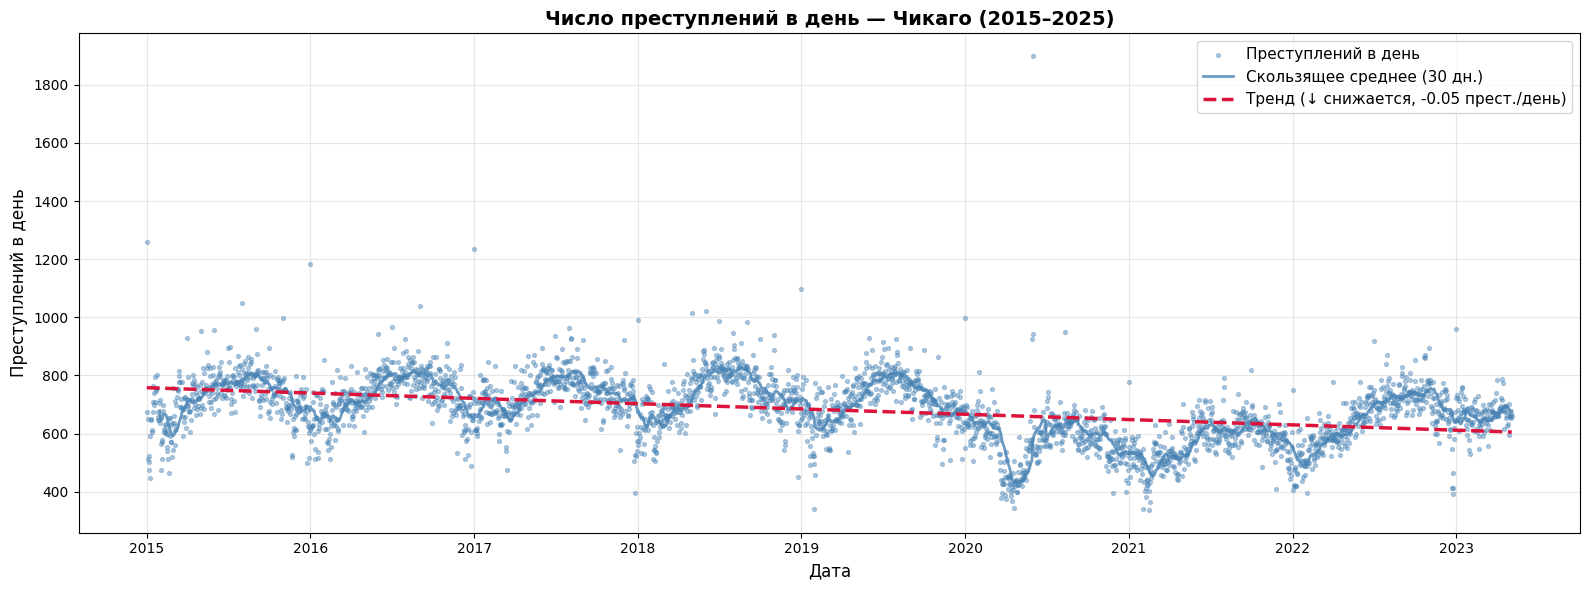

Наклон тренда: -0.0500 преступлений в день
За весь период: ~-152 преступлений/день


In [ ]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(16, 6))

# Точки ряда
ax.scatter(
    df_final["date"], df_final["count"],
    color="steelblue", s=8, alpha=0.4, zorder=2, label="Преступлений в день"
)

# Скользящее среднее 30 дней (сглаживает шум)
rolling = df_final.set_index("date")["count"].rolling(30).mean()
ax.plot(
    rolling.index, rolling.values,
    color="steelblue", linewidth=2, alpha=0.8, zorder=3, label="Скользящее среднее (30 дн.)"
)

# Линия тренда
x_numeric   = (df_final["date"] - df_final["date"].min()).dt.days.values
y_values    = df_final["count"].values
trend_coefs = np.polyfit(x_numeric, y_values, deg=1)
trend_line  = np.polyval(trend_coefs, x_numeric)

direction = "↓ снижается" if trend_coefs[0] < 0 else "↑ растёт"

ax.plot(
    df_final["date"], trend_line,
    color="crimson", linewidth=2.5, linestyle="--", zorder=4,
    label=f"Тренд ({direction}, {trend_coefs[0]:+.2f} прест./день)"
)

ax.set_title("Число преступлений в день — Чикаго (2015–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Преступлений в день", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Наклон тренда: {trend_coefs[0]:+.4f} преступлений в день")
print(f"За весь период: {trend_coefs[0] * x_numeric[-1]:+.0f} преступлений/день")

# Этап 3. Интерпретация и диагностика моделей

https://centraluniversity.yonote.ru/share/6c65f844-c8da-49ff-9720-986c8beb33d1/doc/proekt-na-kurse-machine-learning-magistratura-xsYWrXYIRs

In [ ]:
!pip install optuna lightgbm shap lime -q

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# ФИНАЛЬНАЯ МОДЕЛЬ — Optuna + LightGBM

# Временное разбиение
CUTOFF = pd.Timestamp("2022-01-01")
train_mask = daily_ml["date"] < CUTOFF
test_mask  = daily_ml["date"] >= CUTOFF

X_train = daily_ml.loc[train_mask, STABLE_FEATURES]
y_train = daily_ml.loc[train_mask, "count"]
X_test  = daily_ml.loc[test_mask,  STABLE_FEATURES]
y_test  = daily_ml.loc[test_mask,  "count"]

tscv = TimeSeriesSplit(n_splits=5)

# Optuna
def objective(trial):
    params = {
        "n_estimators" : trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves" : trial.suggest_int("num_leaves", 16, 128),
        "max_depth" : trial.suggest_int("max_depth", 3, 10),
        "min_child_samples" : trial.suggest_int("min_child_samples", 10, 100),
        "subsample" : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha" : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda" : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state" : 42,
        "verbose" : -1,
    }
    cv_scores = []
    for fold_train_idx, fold_val_idx in tscv.split(X_train):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_train.iloc[fold_train_idx], y_train.iloc[fold_train_idx],
            eval_set=[(X_train.iloc[fold_val_idx], y_train.iloc[fold_val_idx])],
            callbacks=[lgb.early_stopping(30, verbose=False)]
        )
        preds = model.predict(X_train.iloc[fold_val_idx])
        cv_scores.append(mean_absolute_error(y_train.iloc[fold_val_idx], preds))
    return np.mean(cv_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nЛучший MAE (CV): {study.best_value:.2f}")
print(f"Лучшие параметры: {study.best_params}")

# Обучаем финальную модель на лучших параметрах
best_params = study.best_params | {"random_state": 42, "verbose": -1}

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2   = r2_score(y_test, y_pred_final)
mape = np.mean(np.abs((y_test - y_pred_final) / y_test)) * 100

print(f"\nФинальная модель (LightGBM + Optuna)")
print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R² = {r2:.3f}")
print(f"MAPE = {mape:.2f}%")

# Добавляем предсказания в датафрейм
daily_ml["prediction"] = np.nan
daily_ml.loc[test_mask, "prediction"] = y_pred_final

  0%|          | 0/50 [00:00<?, ?it/s]


Лучший MAE (CV): 21.32
Лучшие параметры: {'n_estimators': 598, 'learning_rate': 0.02731130717919717, 'num_leaves': 127, 'max_depth': 7, 'min_child_samples': 19, 'subsample': 0.6034161246634479, 'colsample_bytree': 0.9835576574364039, 'reg_alpha': 0.06085112491450203, 'reg_lambda': 0.0041844380574786715}

=== Финальная модель (LightGBM + Optuna) ===
MAE  = 28.12
RMSE = 48.24
R²   = 0.688
MAPE = 3.91%


In [ ]:
# Вторая модель для сравнения интерпретаций: Ridge

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_sc, y_train)

y_pred_ridge = ridge_model.predict(X_test_sc)

mae_r  = mean_absolute_error(y_test, y_pred_ridge)
r2_r   = r2_score(y_test, y_pred_ridge)
print(f"Ridge — MAE={mae_r:.2f}  R²={r2_r:.3f}")

Ridge — MAE=61.64  R²=0.282


SHAP значения посчитаны.
Форма: (2557, 21)


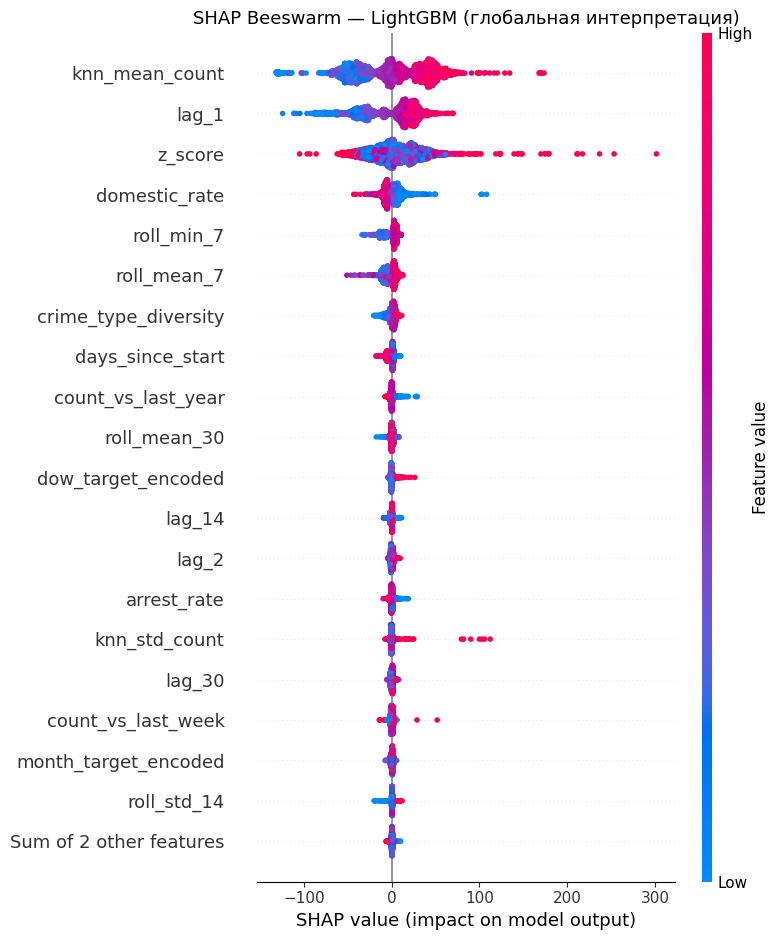

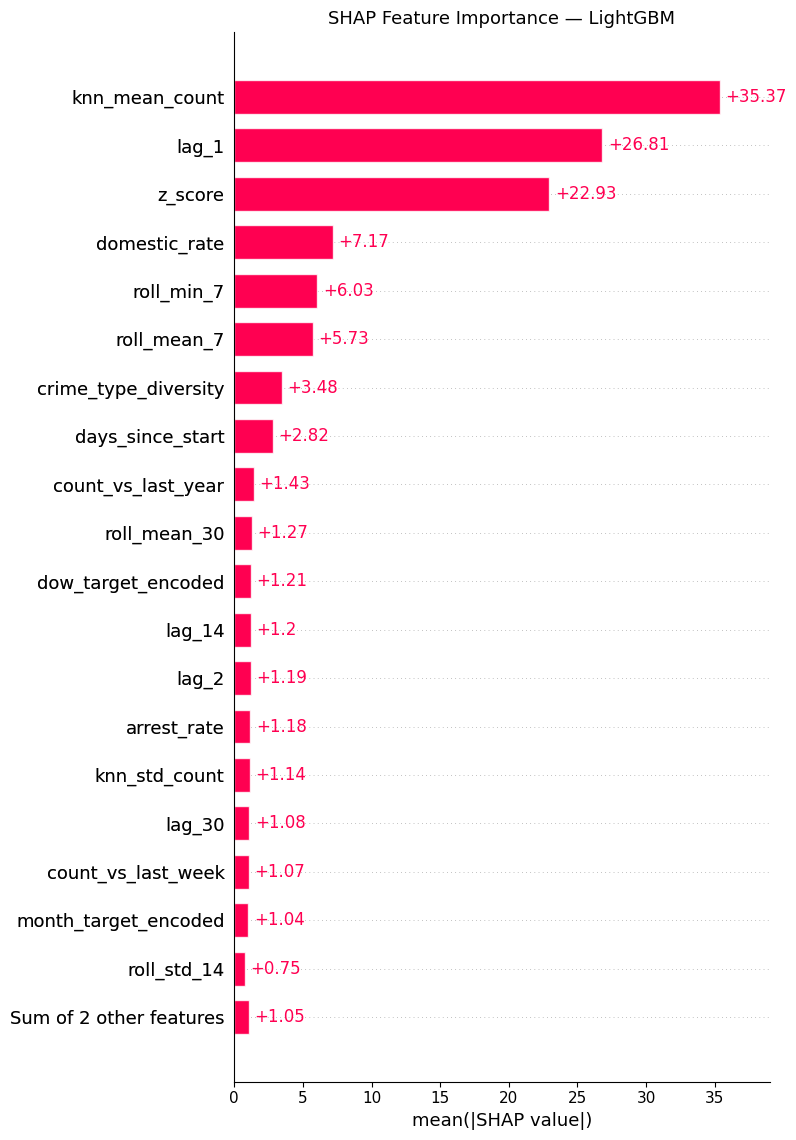

In [ ]:
# ЭТАП 3. ШАГ 1 — ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ (SHAP + LIME)

import shap
import matplotlib.pyplot as plt

shap.initjs()

# 1.1 SHAP — ГЛОБАЛЬНАЯ ИНТЕРПРЕТАЦИЯ

# SHAP для LightGBM
explainer_lgbm  = shap.TreeExplainer(final_model)
shap_values_lgbm = explainer_lgbm(X_train)

print("SHAP значения посчитаны.")
print(f"Форма: {shap_values_lgbm.values.shape}")

# Beeswarm — способ увидеть и важность, и направление влияния
plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_values_lgbm, max_display=20, show=False)
plt.title("SHAP Beeswarm — LightGBM (глобальная интерпретация)", fontsize=13)
plt.tight_layout()
plt.show()

# Только важность
plt.figure(figsize=(12, 10))
shap.plots.bar(shap_values_lgbm, max_display=20, show=False)
plt.title("SHAP Feature Importance — LightGBM", fontsize=13)
plt.tight_layout()
plt.show()

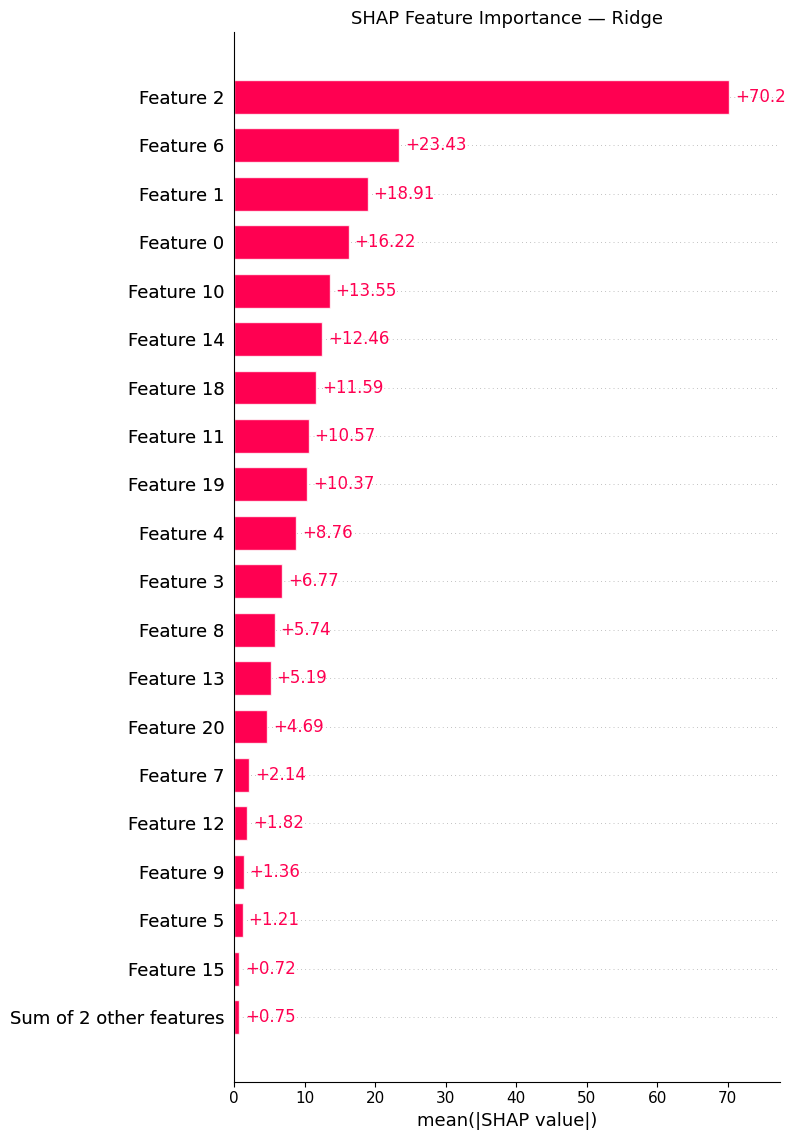

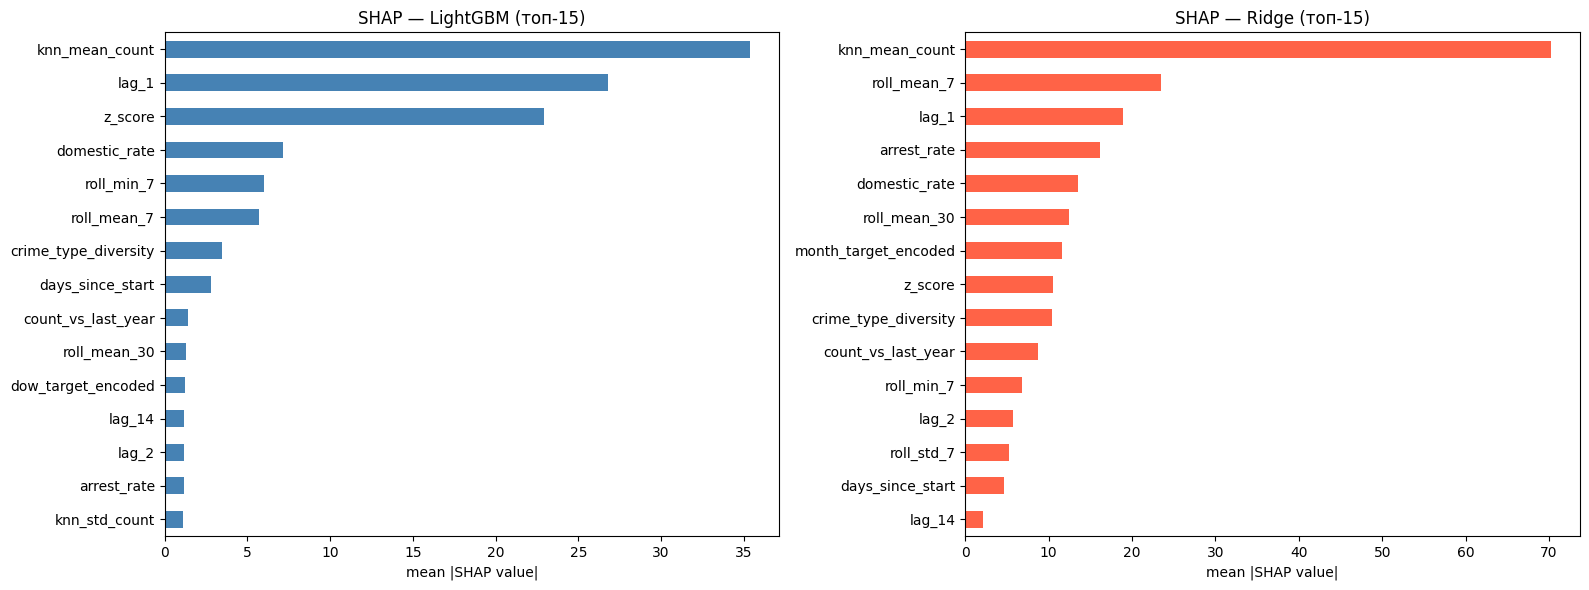


Признаки в топ-10 у обеих моделей (8):
['count_vs_last_year', 'crime_type_diversity', 'domestic_rate', 'knn_mean_count', 'lag_1', 'roll_mean_30', 'roll_mean_7', 'z_score']


In [ ]:
# SHAP для Ridge (LinearExplainer)
explainer_ridge = shap.LinearExplainer(ridge_model, X_train_sc)
shap_values_ridge = explainer_ridge(X_test_sc)

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values_ridge, max_display=20, show=False)
plt.title("SHAP Feature Importance - Ridge", fontsize=13)
plt.tight_layout()
plt.show()

# Сравнение топ-признаков двух моделей
lgbm_top = pd.Series(
    np.abs(shap_values_lgbm.values).mean(axis=0),
    index=STABLE_FEATURES
).sort_values(ascending=False).head(15)

ridge_top = pd.Series(
    np.abs(shap_values_ridge.values).mean(axis=0),
    index=STABLE_FEATURES
).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lgbm_top.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("SHAP — LightGBM (топ-15)", fontsize=12)
axes[0].set_xlabel("mean |SHAP value|")

ridge_top.plot(kind="barh", ax=axes[1], color="tomato")
axes[1].invert_yaxis()
axes[1].set_title("SHAP — Ridge (топ-15)", fontsize=12)
axes[1].set_xlabel("mean |SHAP value|")

plt.tight_layout()
plt.show()

# Пересечение топ-10 признаков у обеих моделей
common = set(lgbm_top.head(10).index) & set(ridge_top.head(10).index)
print(f"\nПризнаки в топ-10 у обеих моделей ({len(common)}):")
print(sorted(common))

Выбранное наблюдение:
  Дата      : 2022-10-23
  Факт      : 872
  Предсказ. : 619
  Ошибка    : 253


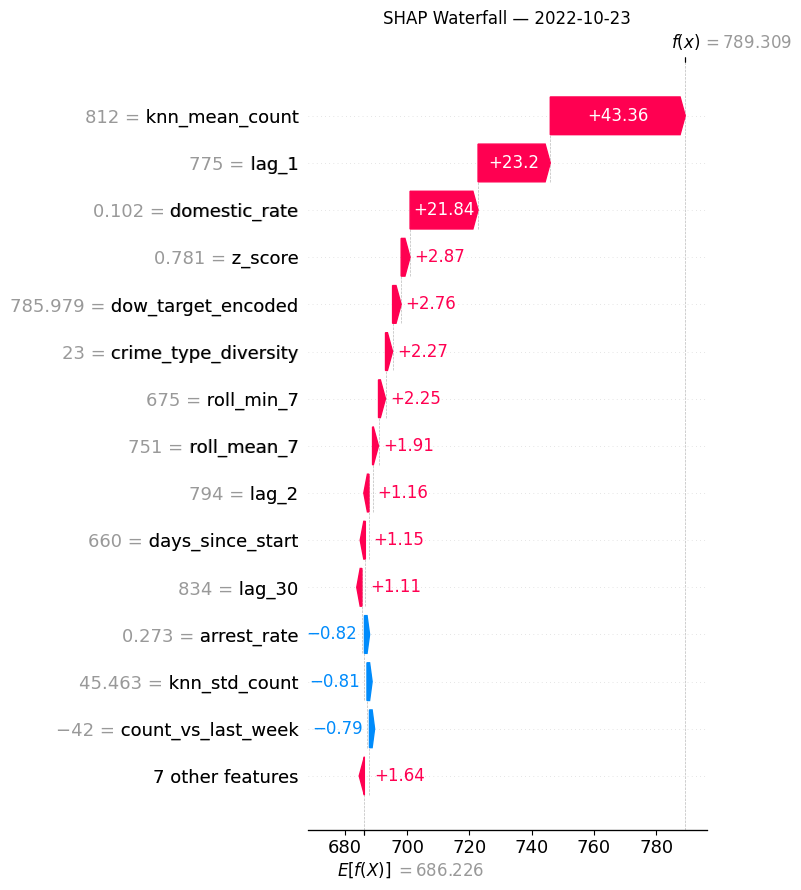

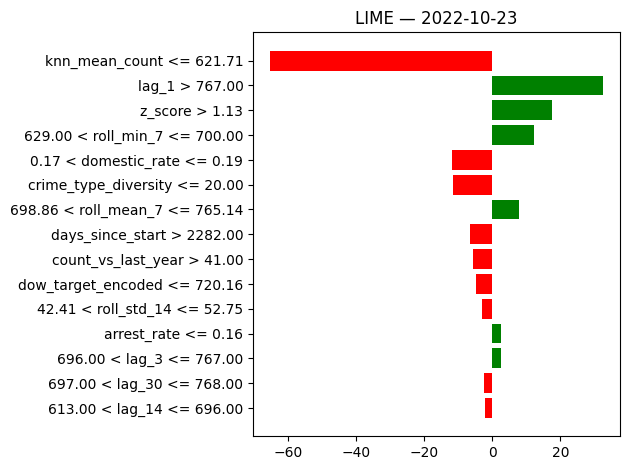


Топ-10 признаков: SHAP vs LIME
Empty DataFrame
Columns: [SHAP, LIME]
Index: []


In [ ]:
# 1.2 LIME + SHAP — ЛОКАЛЬНАЯ ИНТЕРПРЕТАЦИЯ одного наблюдения

from lime import lime_tabular

# Выбираем одно интересное наблюдение — день с максимальной ошибкой
errors = np.abs(y_test.values - y_pred_final)
worst_idx = np.argmax(errors)
obs_idx = X_test.index[worst_idx]

print(f"Выбранное наблюдение:")
print(f"Дата : {daily_ml.loc[obs_idx, 'date'].date()}")
print(f"Факт : {y_test.iloc[worst_idx]:.0f}")
print(f"Предсказание : {y_pred_final[worst_idx]:.0f}")
print(f"Ошибка : {errors[worst_idx]:.0f}")

# SHAP локальный: Waterfall
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_lgbm[worst_idx], max_display=15, show=False)
plt.title(f"SHAP Waterfall — {daily_ml.loc[obs_idx, 'date'].date()}", fontsize=12)
plt.tight_layout()
plt.show()

# LIME локальный
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = STABLE_FEATURES,
    mode = "regression",
    random_state = 42
)

lime_exp = lime_explainer.explain_instance(
    data_row = X_test.iloc[worst_idx].values,
    predict_fn = final_model.predict,
    num_features = 15
)

lime_exp.as_pyplot_figure()
plt.title(f"LIME — {daily_ml.loc[obs_idx, 'date'].date()}", fontsize=12)
plt.tight_layout()
plt.show()

# Сравнение LIME vs SHAP для этого наблюдения
lime_feats = {f: w for f, w in lime_exp.as_list()}
shap_feats = dict(zip(STABLE_FEATURES, shap_values_lgbm.values[worst_idx]))

compare_local = pd.DataFrame({
    "SHAP" : shap_feats,
    "LIME" : lime_feats
}).dropna().sort_values("SHAP", ascending=False, key=abs)

print("\nТоп-10 признаков: SHAP vs LIME")
print(compare_local.head(10).round(3).to_string())

In [ ]:
# ЭТАП 3. ШАГ 2 — SHAP-ЭМБЕДДИНГИ И КЛАСТЕРИЗАЦИЯ

# 2.1 Получаем SHAP-эмбеддинги как функцию


def get_shap_embeddings(model, X):
    """
    Возвращает SHAP-значения в виде матрицы (n_samples, n_features).
    Каждая строка — это "SHAP-портрет" наблюдения в пространстве признаков.
    """
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer(X)
    return shap_vals.values

# Считаем эмбеддинги на всём train
shap_embeddings = get_shap_embeddings(final_model, X_train)
print(f"SHAP-эмбеддинги: {shap_embeddings.shape}  (дней х признаков)")

SHAP-эмбеддинги: (2557, 21)  (дней × признаков)


In [ ]:
!pip install umap-learn -q

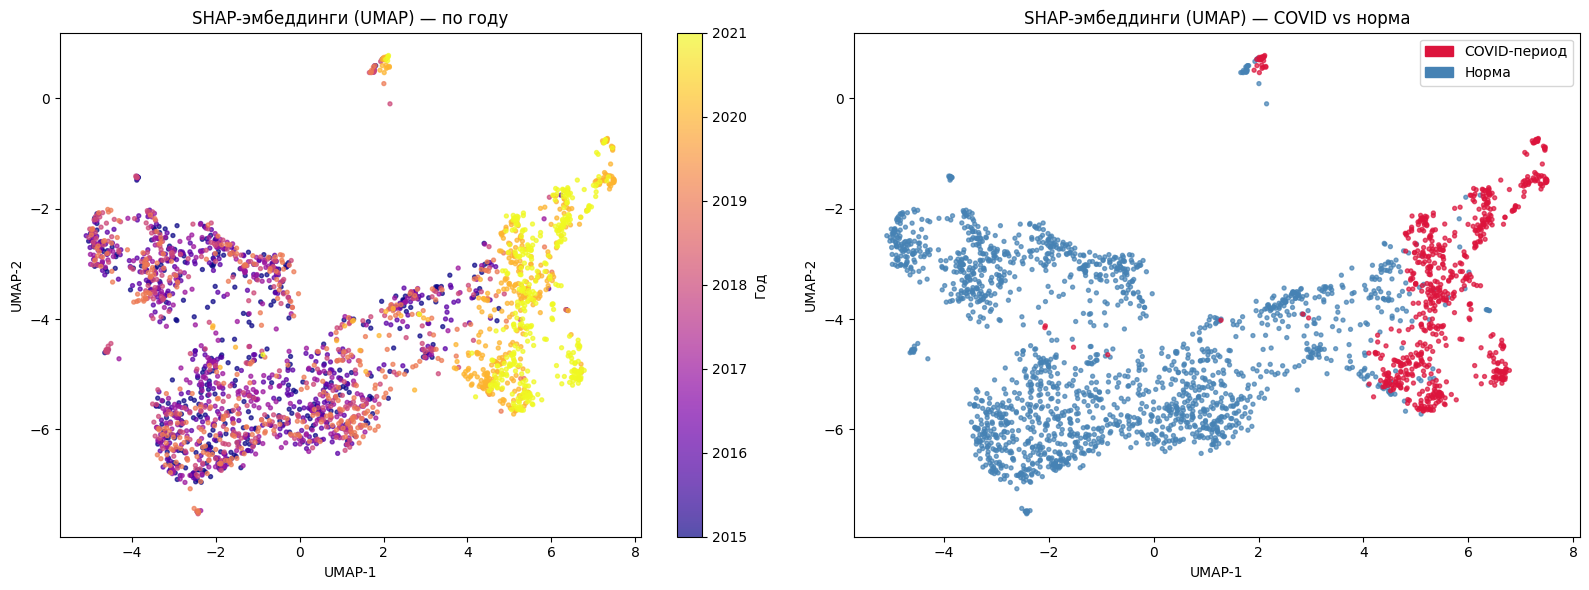

In [ ]:
# 2.2 Поиск сдвигов и аномалий через SHAP-эмбеддинги

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap

# Нормализуем эмбеддинги
scaler_shap = StandardScaler()
shap_scaled = scaler_shap.fit_transform(shap_embeddings)

# Снижаем размерность до 2D через UMAP для визуализации
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
shap_2d = reducer.fit_transform(shap_scaled)

# Раскрашиваем по году — ищем сдвиги
daily_ml['year'] = daily_ml['date'].dt.year

years_train = daily_ml.loc[train_mask, "year"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(shap_2d[:, 0], shap_2d[:, 1],
                       c=years_train, cmap="plasma", s=8, alpha=0.7)
plt.colorbar(sc1, ax=axes[0], label="Год")
axes[0].set_title("SHAP-эмбеддинги (UMAP) — по году", fontsize=12)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

# По COVID-периоду
covid_flag = daily_ml.loc[train_mask, "is_covid_lockdown"].values
colors_covid = ["crimson" if c else "steelblue" for c in covid_flag]
axes[1].scatter(shap_2d[:, 0], shap_2d[:, 1],
                c=colors_covid, s=8, alpha=0.7)
axes[1].set_title("SHAP-эмбеддинги (UMAP) — COVID vs норма", fontsize=12)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color="crimson",   label="COVID-период"),
    Patch(color="steelblue", label="Норма")
])

plt.tight_layout()
plt.show()

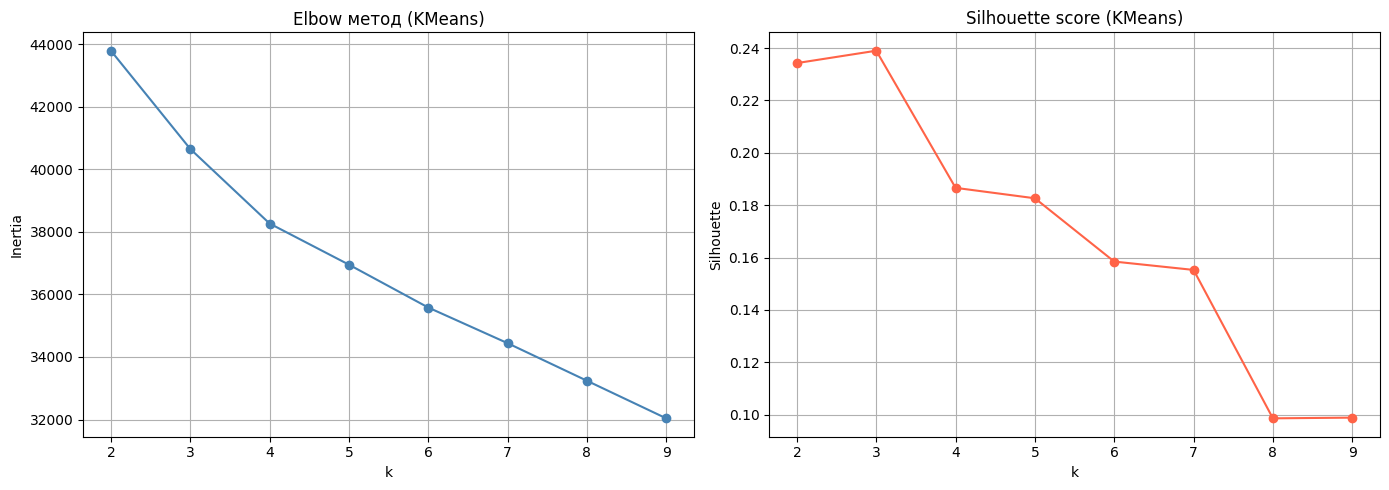

Оптимальное k = 3  (Silhouette = 0.239)


In [ ]:
# 2.3 Кластеризация SHAP-эмбеддингов

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# KMeans: подбираем оптимальное k через Elbow + Silhouette
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(shap_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(shap_scaled, labels, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow метод (KMeans)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, marker="o", color="tomato")
axes[1].set_title("Silhouette score (KMeans)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Оптимальное k = {best_k}  (Silhouette = {max(silhouettes):.3f})")

KMeans:         (array([0, 1, 2], dtype=int32), array([   7, 1546, 1004]))
Agglomerative:  (array([0, 1, 2]), array([1241, 1308,    8]))
DBSCAN кластеров: 2, шума: 2014


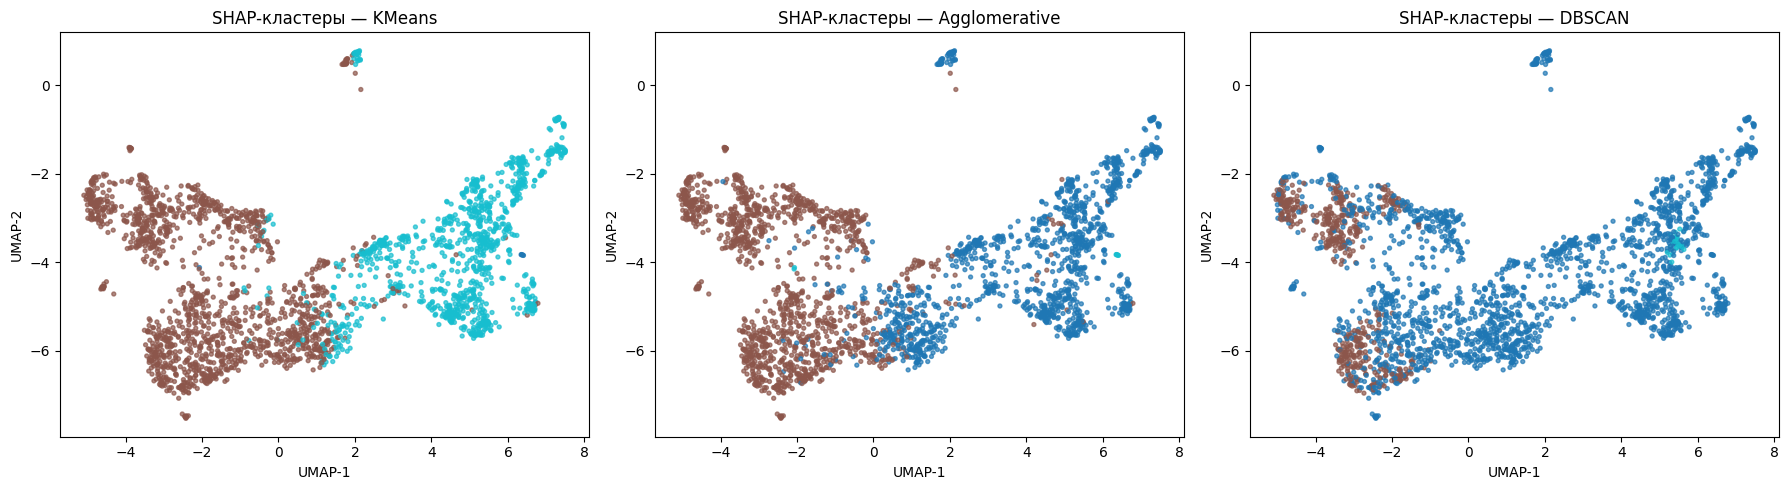

In [ ]:
# Финальные кластеры тремя методами
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = km_final.fit_predict(shap_scaled)

agg = AgglomerativeClustering(n_clusters=best_k)
labels_ag = agg.fit_predict(shap_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=20)
labels_db = dbscan.fit_predict(shap_scaled)

print(f"KMeans: {np.unique(labels_km, return_counts=True)}")
print(f"Agglomerative:{np.unique(labels_ag, return_counts=True)}")
print(f"DBSCAN кластеров: {len(set(labels_db)) - (1 if -1 in labels_db else 0)}, "
      f"шума: {(labels_db == -1).sum()}")

# Визуализация кластеров на UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, labels, title in zip(
    axes,
    [labels_km, labels_ag, labels_db],
    ["KMeans", "Agglomerative", "DBSCAN"]
):
    sc = ax.scatter(shap_2d[:, 0], shap_2d[:, 1],
                    c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"SHAP-кластеры — {title}", fontsize=12)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

In [ ]:
# 2.4 Интерпретация кластеров + добавление в модель

# Используем KMeans как финальный (наиболее стабильный)
daily_ml.loc[train_mask, "shap_cluster"] = labels_km
daily_ml["shap_cluster"] = daily_ml["shap_cluster"].fillna(-1).astype(int)

# Профиль каждого кластера
cluster_profile = daily_ml.loc[train_mask].groupby("shap_cluster").agg(
    avg_crimes = ("count", "mean"),
    std_crimes = ("count", "std"),
    avg_covid  = ("is_covid_lockdown", "mean"),
    # avg_weekend= ("is_weekend", "mean"),
    count_days = ("count", "size"),
    year_min   = ("year", "min"),
    year_max   = ("year", "max"),
).round(2)

print("Профиль кластеров:")
display(cluster_profile)

# Переобучаем модель с признаком кластера
FEATURES_WITH_CLUSTER = STABLE_FEATURES + ["shap_cluster"]

# На test кластер определяем через predict KMeans
shap_test_embs  = get_shap_embeddings(final_model, X_test)
shap_test_scaled = scaler_shap.transform(shap_test_embs)
daily_ml.loc[test_mask, "shap_cluster"] = km_final.predict(shap_test_scaled)

model_with_cluster = lgb.LGBMRegressor(**best_params)
model_with_cluster.fit(
    daily_ml.loc[train_mask, FEATURES_WITH_CLUSTER],
    y_train
)

y_pred_cluster = model_with_cluster.predict(
    daily_ml.loc[test_mask, FEATURES_WITH_CLUSTER]
)

mae_cl = mean_absolute_error(y_test, y_pred_cluster)
r2_cl  = r2_score(y_test, y_pred_cluster)

daily_ml.loc[test_mask, "prediction_new"] = y_pred_cluster

print(f"\nС признаком кластера:  MAE={mae_cl:.2f}  R²={r2_cl:.3f}")
print(f"Без признака кластера: MAE={mae:.2f}  R²={r2:.3f}")
print(f"Изменение MAE: {mae_cl - mae:+.2f}")

Профиль кластеров:


,avg_crimes,std_crimes,avg_covid,count_days,year_min,year_max
shap_cluster,,,,,,
0,1193.29,332.43,0.29,7,2015,2020
1,753.35,66.48,0.00,1546,2015,2021
2,579.33,72.97,0.65,1004,2015,2021



С признаком кластера:  MAE=20.56  R²=0.790
Без признака кластера: MAE=28.12  R²=0.688
Изменение MAE: -7.56


In [ ]:
# ЭТАП 3. ШАГ 3 — ВАЛИДАЦИЯ + SHAPLEY FLOW

# 3.1 Кросс-валидация: только эмбеддинги vs эмбеддинги + признаки

from sklearn.model_selection import TimeSeriesSplit

tscv_val = TimeSeriesSplit(n_splits=5)

mae_emb_only = []
mae_emb_plus = []

for fold, (tr_idx, val_idx) in enumerate(tscv_val.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # Обучаем базовую модель на fold
    m_fold = lgb.LGBMRegressor(**best_params)
    m_fold.fit(X_tr, y_tr)

    # SHAP-эмбеддинги на train-части fold
    emb_tr  = get_shap_embeddings(m_fold, X_tr)
    emb_val = shap.TreeExplainer(m_fold)(X_val).values

    sc_fold = StandardScaler()
    emb_tr_sc  = sc_fold.fit_transform(emb_tr)
    emb_val_sc = sc_fold.transform(emb_val)

    # Вариант 1: только эмбеддинги
    m_emb = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
    m_emb.fit(emb_tr_sc, y_tr)
    mae_emb_only.append(mean_absolute_error(y_val, m_emb.predict(emb_val_sc)))

    # Вариант 2: эмбеддинги + исходные признаки
    X_concat_tr = np.hstack([X_tr.values,  emb_tr_sc])
    X_concat_val = np.hstack([X_val.values, emb_val_sc])

    m_concat = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
    m_concat.fit(X_concat_tr, y_tr)
    mae_emb_plus.append(mean_absolute_error(y_val, m_concat.predict(X_concat_val)))

    print(f"Fold {fold+1}: only_emb={mae_emb_only[-1]:.1f}  concat={mae_emb_plus[-1]:.1f}")

print(f"\nСредний MAE (только эмбеддинги):      {np.mean(mae_emb_only):.2f} ± {np.std(mae_emb_only):.2f}")
print(f"Средний MAE (эмбеддинги + признаки):   {np.mean(mae_emb_plus):.2f} ± {np.std(mae_emb_plus):.2f}")
print(f"Финальная модель (Optuna, без concat):  {mae:.2f}")

Fold 1: only_emb=29.8  concat=28.0
Fold 2: only_emb=21.7  concat=20.4
Fold 3: only_emb=19.5  concat=19.6
Fold 4: only_emb=36.6  concat=30.9
Fold 5: only_emb=15.2  concat=14.8

Средний MAE (только эмбеддинги):      24.57 ± 7.66
Средний MAE (эмбеддинги + признаки):   22.74 ± 5.89
Финальная модель (Optuna, без concat):  28.12


shapflow не установлен — строим SHAP interaction values

Топ-15 взаимодействий признаков (Shapley Interaction Values):
          feat_1         feat_2  interaction
  knn_mean_count        z_score     9.943486
           lag_1        z_score     8.881335
  knn_mean_count          lag_1     6.342478
     roll_mean_7        z_score     3.337556
   domestic_rate        z_score     2.992039
   domestic_rate knn_mean_count     2.695587
           lag_1    roll_mean_7     2.329528
  knn_mean_count     roll_min_7     2.314783
      roll_min_7        z_score     2.310576
  knn_mean_count    roll_mean_7     1.520734
   domestic_rate          lag_1     1.412645
    roll_mean_30        z_score     0.947131
   domestic_rate    roll_mean_7     0.777425
days_since_start          lag_1     0.678280
days_since_start knn_mean_count     0.654679


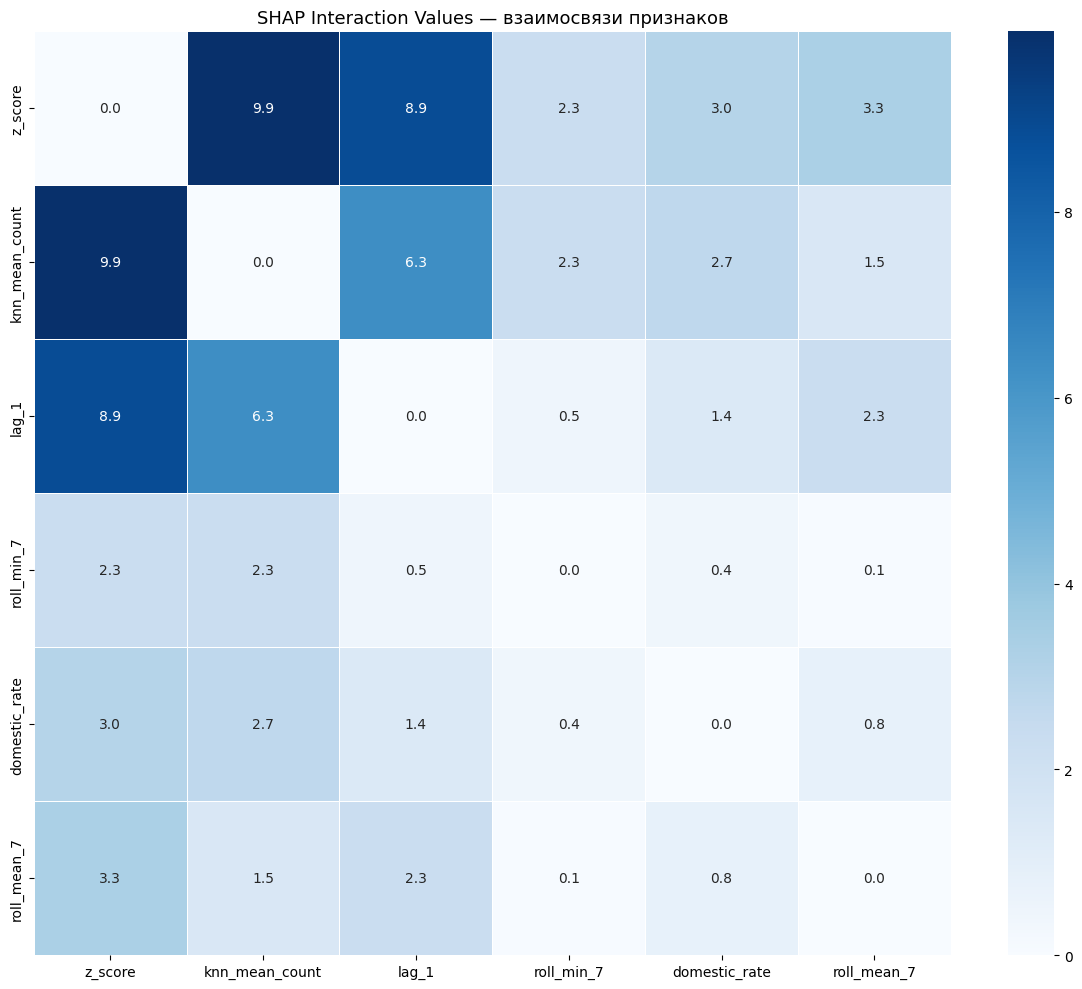

In [ ]:
# 3.2 SHAPLEY FLOW — граф взаимосвязей признаков

# Считаем попарные взаимодействия (на подвыборке — долго считать)
sample_idx  = np.random.choice(len(X_train), size=500, replace=False)
X_sample    = X_train.iloc[sample_idx]

explainer_int  = shap.TreeExplainer(final_model)
shap_interact  = explainer_int.shap_interaction_values(X_sample)

# Матрица взаимодействий: среднее |interaction value|
interaction_matrix = np.abs(shap_interact).mean(axis=0)
np.fill_diagonal(interaction_matrix, 0)

interact_df = pd.DataFrame(
    interaction_matrix,
    index=STABLE_FEATURES,
    columns=STABLE_FEATURES
)

# Топ-10 попарных взаимодействий
pairs = (
    interact_df.stack()
    .reset_index()
    .rename(columns={"level_0": "feat_1", "level_1": "feat_2", 0: "interaction"})
)
pairs = pairs[pairs["feat_1"] < pairs["feat_2"]].sort_values("interaction", ascending=False)

print("\nТоп-15 взаимодействий признаков (Shapley Interaction Values):")
print(pairs.head(15).to_string(index=False))

# Heatmap взаимодействий (топ-15 признаков)
top_feats = list(set(pairs.head(10)["feat_1"].tolist() + pairs.head(10)["feat_2"].tolist()))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    interact_df.loc[top_feats, top_feats],
    ax=ax, cmap="Blues", annot=True, fmt=".1f", linewidths=0.5
)
ax.set_title("SHAP Interaction Values — взаимосвязи признаков", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 3.3 ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

results_final = pd.DataFrame([
    {"Модель": "Ridge (baseline)", "MAE": mae_r, "R²": r2_r},
    {"Модель": "LightGBM + Optuna", "MAE": mae, "R²": r2},
    {"Модель": "LightGBM + SHAP-кластер", "MAE": mae_cl, "R²": r2_cl},
    {"Модель": "SHAP-эмбеддинги (только)", "MAE": np.mean(mae_emb_only), "R²": None},
    {"Модель": "SHAP-эмбеддинги + признаки", "MAE": np.mean(mae_emb_plus), "R²": None},
]).round(3)


display(results_final)


,Модель,MAE,R²
0,Ridge (baseline),61.644,0.282
1,LightGBM + Optuna,28.120,0.688
2,LightGBM + SHAP-кластер,20.564,0.790
3,SHAP-эмбеддинги (только),24.566,NaN
4,SHAP-эмбеддинги + признаки,22.744,NaN


In [ ]:
daily_ml.query("date >= '2023-01-01'")

,date,count,z_score,anomaly_z,anomaly_iqr,is_new_year,blm_protest,is_summer_peak,is_extreme_cold,is_covid_lockdown,...,roll_std_30,roll_max_30,roll_min_30,days_since_start,count_vs_last_week,count_vs_last_year,prediction,year,shap_cluster,prediction_new
2922,2023-01-01,959,2.419126,False,False,1,0,0,0,1,...,101.836747,773.0,393.0,3287,331.0,-27.0,1154.888711,2023,0,1177.103352
2923,2023-01-02,648,0.380317,False,False,0,0,0,0,1,...,115.190721,959.0,393.0,3288,547.0,554.0,660.564638,2023,2,657.554577
2924,2023-01-03,733,0.384804,False,False,0,0,0,0,1,...,115.179620,959.0,393.0,3289,182.0,225.0,681.430653,2023,1,687.791610
2925,2023-01-04,680,0.092271,False,False,0,0,0,0,1,...,116.062330,959.0,393.0,3290,150.0,259.0,675.040613,2023,2,691.269065
2926,2023-01-05,653,0.335310,False,False,0,0,0,0,1,...,116.062330,959.0,393.0,3291,62.0,261.0,654.343183,2023,1,684.984219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3042,2023-05-01,668,0.200288,False,False,0,0,0,0,1,...,43.432455,787.0,595.0,3407,9.0,-43.0,683.614460,2023,2,673.963030
3043,2023-05-02,657,0.299304,False,False,0,0,0,0,1,...,39.130551,787.0,595.0,3408,43.0,87.0,669.021800,2023,2,657.310089
3044,2023-05-03,654,0.326308,False,False,0,0,0,0,1,...,39.315830,787.0,595.0,3409,-5.0,106.0,651.873442,2023,2,650.088387
3045,2023-05-04,671,0.173284,False,False,0,0,0,0,1,...,39.483286,787.0,595.0,3410,22.0,40.0,676.240065,2023,2,686.120361


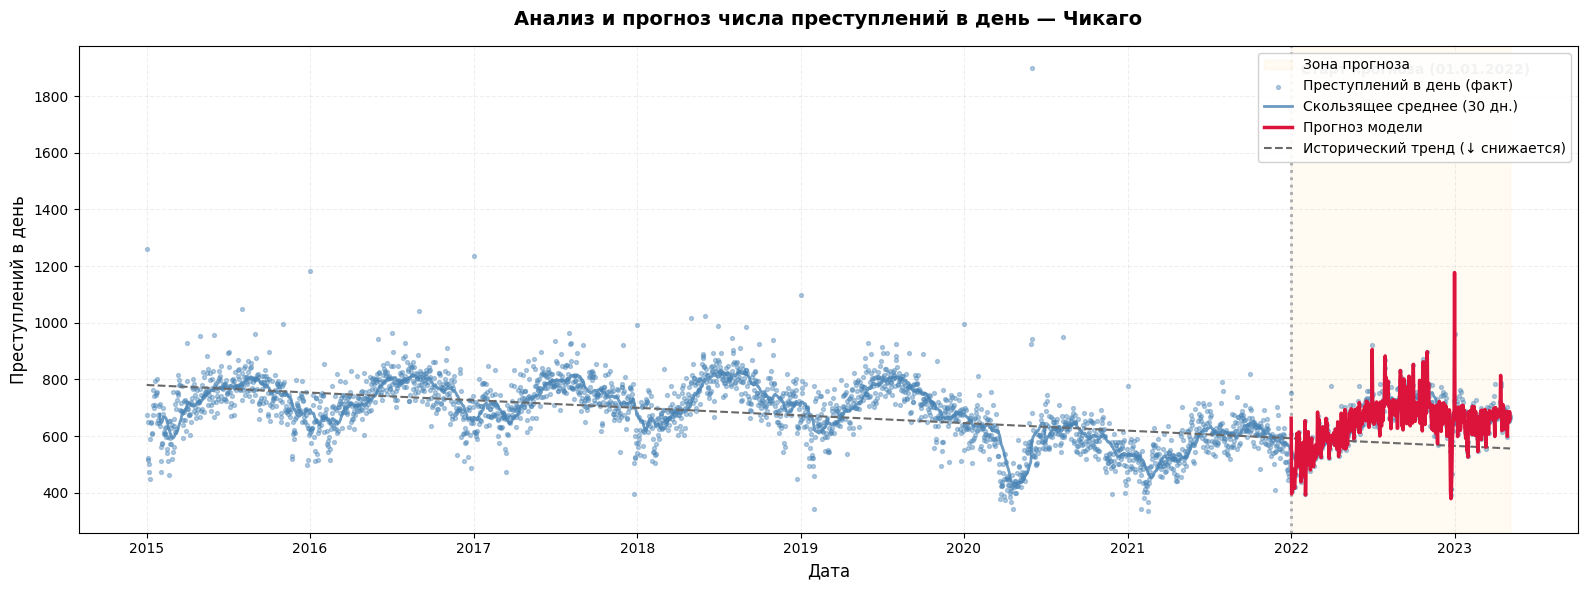

In [ ]:
daily_ml['prediction'] = daily_ml['prediction'].fillna(daily_ml['count'])
daily_ml['prediction_new'] = daily_ml['prediction_new'].fillna(daily_ml['count'])

fig, ax = plt.subplots(figsize=(16, 6))

cutoff_date = pd.Timestamp("2022-01-01")
ax.axvline(
    cutoff_date, color="darkgray", linestyle=":", linewidth=2, zorder=1
)
ax.axvspan(
    cutoff_date,
    daily_ml["date"].max(),
    color="orange",
    alpha=0.05,
    label="Зона прогноза",
    zorder=0,
)

ax.scatter(
    daily_ml["date"],
    daily_ml["count"],
    color="steelblue",
    s=8,
    alpha=0.4,
    zorder=2,
    label="Преступлений в день (факт)",
)

rolling = daily_ml.set_index("date")["count"].rolling(30).mean()
ax.plot(
    rolling.index,
    rolling.values,
    color="steelblue",
    linewidth=2,
    alpha=0.8,
    zorder=3,
    label="Скользящее среднее (30 дн.)",
)

df_pred = daily_ml[daily_ml["date"] >= cutoff_date].dropna(subset=["prediction_new"])

ax.plot(
    df_pred["date"],
    df_pred["prediction_new"],
    color="crimson",
    linewidth=2.5,
    linestyle="-",
    zorder=4,
    label="Прогноз модели",
)

df_hist = daily_ml[daily_ml["date"] < cutoff_date]
x_numeric = (df_hist["date"] - df_hist["date"].min()).dt.days.values
y_values = df_hist["count"].values

trend_coefs = np.polyfit(x_numeric, y_values, deg=1)
direction = "↓ снижается" if trend_coefs[0] < 0 else "↑ растёт"

x_full = (daily_ml["date"] - df_hist["date"].min()).dt.days.values
trend_line_full = np.polyval(trend_coefs, x_full)

ax.plot(
    daily_ml["date"],
    trend_line_full,
    color="dimgray",
    linewidth=1.5,
    linestyle="--",
    zorder=3,
    label=f"Исторический тренд ({direction})",
)

ax.set_title(
    "Анализ и прогноз числа преступлений в день — Чикаго",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Преступлений в день", fontsize=12)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.2, linestyle="--")

ax.legend(loc="upper right", fontsize=10, framealpha=0.9)

# ax.text(
#     cutoff_date,
#     ax.get_ylim()[1] * 0.95,
#     "  Старт прогноза (01.01.2022)",
#     color="gray",
#     fontweight="bold",
# )

plt.tight_layout()
plt.show()